# 📊 Analisis Mendalam Pasar Kerja Indonesia — Glints Dataset Final

> **Role:** Senior Data Analyst  
> **Dataset:** `full_dataset_glints.csv` — +60.000 lowongan kerja dari platform Glints  
> **Struktur Hierarki:** `Industry (L1) → Job_Category_parent (L2) → Job_Category (L3)`

---

## 🎯 Pertanyaan Bisnis yang Akan Dijawab

| # | Pertanyaan | Relevansi |
|---|---|---|
| 1 | Industri mana yang paling aktif merekrut? | Target pencarian kerja |
| 2 | Apakah experience berkorelasi signifikan dengan salary? | Salary expectation & ROI karir |
| 3 | Skill apa yang paling *premium* (mengangkat salary)? | Career investment decision |
| 4 | Domain mana yang High Demand tapi Low Salary (oversupply)? | Red flag untuk job seeker |
| 5 | Remote work tersedia di mana saja? | Work arrangement strategy |
| 6 | Apakah pendidikan tinggi menjamin gaji lebih baik? | Education ROI |
| 7 | Skill apa yang paling versatile (lintas industri)? | Universal skill investment |

---
## 0. Import Library & Konfigurasi

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

import re
import unicodedata
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

BLUE   = '#2E86AB'
ORANGE = '#E07B54'
GREEN  = '#55A868'

DATA_PATH = 'full_dataset_glints_v2.csv'
print('✅ Library berhasil diimport.')

✅ Library berhasil diimport.


---
## 1. Data Understanding

### 1.1 Load & Gambaran Awal Dataset

In [16]:
df_raw = pd.read_csv(DATA_PATH)

print(f'📐 Shape      : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom')
print(f'🗂️  Kolom      : {df_raw.columns.tolist()}')
print()
df_raw.head(5)

📐 Shape      : 82,201 baris × 13 kolom
🗂️  Kolom      : ['Job_Link', 'Title', 'Industry', 'Job_Category_parent', 'Job_Category', 'Salary_Mode', 'Min_Salary', 'Max_Salary', 'Skills', 'Job_Type', 'Work Arrangement', 'Education', 'Experience']



,Job_Link,Title,Industry,Job_Category_parent,Job_Category,Salary_Mode,Min_Salary,Max_Salary,Skills,Job_Type,Work Arrangement,Education,Experience
0,https://glints.com/id/opportunities/jobs/26fd8...,Driver Taksi,Transportation/Trucking/Railroad,"Supply Chain, Logistics & Transportation",Taxi Driver,MONTH,4000000,8000000.0,"Customer Service, Communication Skills, Driving",FULL_TIME,ONSITE,PRIMARY_SCHOOL,0
1,https://glints.com/id/opportunities/jobs/d75a7...,Supir Taxi Online (Unit dari PT),Transportation/Trucking/Railroad,"Supply Chain, Logistics & Transportation",Taxi Driver,MONTH,5000000,6500000.0,"Driving, Driver Training, Customer Service",FULL_TIME,ONSITE,PRIMARY_SCHOOL,0
2,https://glints.com/id/opportunities/jobs/8431f...,Crew Dapur,Food & Beverages,Services Industry,Kitchen Staff,MONTH,100000,300000.0,"Time Management, Home Cooking, Cook, Teamwork",FULL_TIME,ONSITE,PRIMARY_SCHOOL,0
3,https://glints.com/id/opportunities/jobs/11204...,Driver Bus & Taxi,Transportation/Trucking/Railroad,"Supply Chain, Logistics & Transportation",Taxi Driver,MONTH,5000000,6000000.0,"Teamwork, Customer Service, Driving",FULL_TIME,ONSITE,PRIMARY_SCHOOL,0
4,https://glints.com/id/opportunities/jobs/17888...,Driver Profesional,Transportation/Trucking/Railroad,"Supply Chain, Logistics & Transportation",Taxi Driver,MONTH,800000,1500000.0,"Communication Skills, Customer Service, Driving",FULL_TIME,ONSITE,PRIMARY_SCHOOL,0


In [17]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 82201 entries, 0 to 82200
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Job_Link             82201 non-null  str    
 1   Title                82201 non-null  str    
 2   Industry             80905 non-null  str    
 3   Job_Category_parent  82201 non-null  str    
 4   Job_Category         82201 non-null  str    
 5   Salary_Mode          70586 non-null  str    
 6   Min_Salary           82201 non-null  int64  
 7   Max_Salary           79558 non-null  float64
 8   Skills               82201 non-null  str    
 9   Job_Type             82201 non-null  str    
 10  Work Arrangement     82201 non-null  str    
 11  Education            82201 non-null  str    
 12  Experience           82201 non-null  int64  
dtypes: float64(1), int64(2), str(10)
memory usage: 8.2 MB


### 1.2 Deskripsi Fitur & Hierarki Kategori

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `Job_Link` | string | URL unik per lowongan |
| `Title` | string | Nama posisi pekerjaan |
| `Industry` | string | Bidang industri perusahaan yang sedang hiring (**Level 1**)|
| `Job_Category_parent` | string | Fungsi pekerjaan utama (**Level 2**) |
| `Job_Category` | string | Pekerjaan Detail (**Level 3**) |
| `Salary_Mode` | string | MONTH / YEAR / HOUR / WEEK / DAY / PROJECT |
| `Min_Salary` | numeric | Batas bawah gaji |
| `Max_Salary` | numeric | Batas atas gaji |
| `Skills` | string | Daftar skill (comma-separated) |
| `Job_Type` | string | FULL_TIME, CONTRACT, INTERNSHIP, PART_TIME, PROJECT_BASED |
| `Work Arrangement` | string | ONSITE / REMOTE / HYBRID |
| `Education` | string | Pendidikan minimum (ordinal kategori) |
| `Experience` | integer | Pengalaman minimum: 0, 1, 3, 5, 10 tahun |

```
Hierarki:
  Industry                               ← Level 1
    └── Job_Category_parent              ← Level 2
          └── Job_Category               ← Level 3
```

### 1.3 Distribusi Tiap Level Hierarki

Unique Industry (L1)           : 140
Unique Job_Category_parent (L2): 65
Unique Job_Category (L3)       : 629


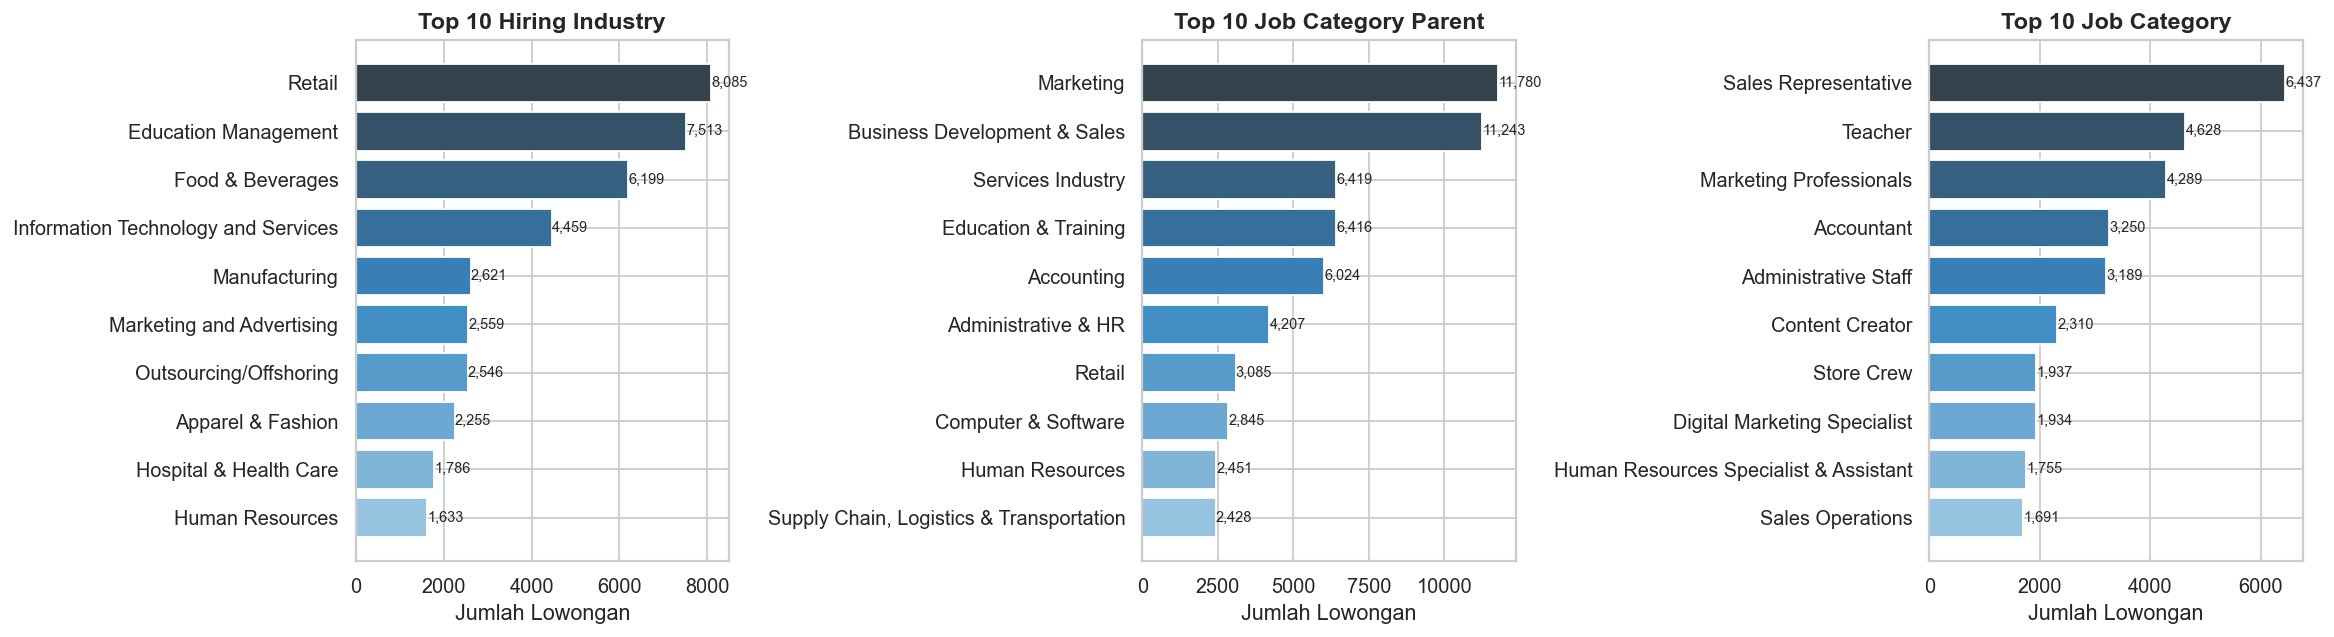

In [18]:
print(f'Unique Industry (L1)           : {df_raw["Industry"].nunique()}')
print(f'Unique Job_Category_parent (L2): {df_raw["Job_Category_parent"].nunique()}')
print(f'Unique Job_Category (L3)       : {df_raw["Job_Category"].nunique()}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, top_n, label in [
    (axes[0], 'Industry',            10, 'Hiring Industry'),
    (axes[1], 'Job_Category_parent', 10, 'Job Category Parent'),
    (axes[2], 'Job_Category',        10, 'Job Category'),
]:
    vc = df_raw[col].value_counts().head(top_n)
    ax.barh(vc.index[::-1], vc.values[::-1], color=sns.color_palette('Blues_d', top_n))
    ax.set_title(f'Top {top_n} {label}')
    ax.set_xlabel('Jumlah Lowongan')
    for bar in ax.patches:
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 1.4 Mengidentifikasi Masalah Kualitas Data, seperti Missing Values dan Duplikat

In [19]:
miss = df_raw.isnull().sum()
miss_pct = (miss / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Count': miss, 'Pct (%)': miss_pct})
print('====== Missing Values ======')
print(miss_df[miss_df['Count'] > 0].sort_values('Pct (%)', ascending=False).to_string())

print(f'\nDuplikat penuh      : {df_raw.duplicated().sum():,}')
print(f'Duplikat Job_Link   : {df_raw.duplicated(subset=["Job_Link"]).sum():,}')

print('\n=== Distribusi Salary_Mode ===')
print(df_raw['Salary_Mode'].value_counts(dropna=False).to_string())

df_raw['Min_Salary'] = pd.to_numeric(df_raw['Min_Salary'], errors='coerce')
df_raw['Max_Salary'] = pd.to_numeric(df_raw['Max_Salary'], errors='coerce')
print(f'\nMin_Salary = 0 : {(df_raw["Min_Salary"] == 0).sum():,} baris')
print(f'Min_Salary > Max_Salary      : {(df_raw["Min_Salary"] > df_raw["Max_Salary"].fillna(999e9)).sum():,} baris')

# data dimana Salary_Mode = null juga Min_Salary = 0 dan Max_Salary = 0
mask = df_raw['Salary_Mode'].isnull() & (df_raw['Min_Salary'] == 0) & (df_raw['Max_Salary'] == 0)
print(f'\nData dengan Salary_Mode null juga Min_Salary = 0 dan Max_Salary = 0: {mask.sum():,} baris')

====== Missing Values ======
             Count  Pct (%)
Salary_Mode  11615    14.13
Max_Salary    2643     3.22
Industry      1296     1.58

Duplikat penuh      : 23,052
Duplikat Job_Link   : 24,856

=== Distribusi Salary_Mode ===
Salary_Mode
MONTH      70223
NaN        11615
PROJECT      143
YEAR         137
WEEK          48
DAY           29
HOUR           6

Min_Salary = 0 : 11,962 baris
Min_Salary > Max_Salary      : 0 baris

Data dengan Salary_Mode null juga Min_Salary = 0 dan Max_Salary = 0: 11,615 baris


In [20]:
# tampilkan 5 baris dengan min_salary terbesar
print('\n=== 5 Baris dengan Min_Salary Terbesar ===')
print(df_raw.sort_values('Min_Salary', ascending=False)[['Min_Salary', 'Max_Salary', 'Salary_Mode']].head(5))

# tampilkan 5 baris dengan max_salary terbesar
print('\n=== 5 Baris dengan Max_Salary Terbesar ===')
print(df_raw.sort_values('Max_Salary', ascending=False)[['Min_Salary', 'Max_Salary', 'Salary_Mode']].head(5))


=== 5 Baris dengan Min_Salary Terbesar ===
       Min_Salary   Max_Salary Salary_Mode
60104   205366950  205366951.0       MONTH
60103   205366950  205366951.0       MONTH
60105   205366950  205366951.0       MONTH
60106   205366950  205366951.0       MONTH
55355   150000000  151000000.0       MONTH

=== 5 Baris dengan Max_Salary Terbesar ===
       Min_Salary   Max_Salary Salary_Mode
46039           0  300000000.0       MONTH
50947           0  300000000.0       MONTH
18042           0  255000000.0        YEAR
60106   205366950  205366951.0       MONTH
60105   205366950  205366951.0       MONTH


**📋 Ringkasan Masalah Kualitas Data:**

| Masalah | Jumlah | Strategi |
|---|---|---|
| `Industry` NaN | 414 (1.6%) | Fill `'Unknown'` |
| `Salary_Mode` NaN (salary semua = 0) | 4.055 (15.5%) | Tandai no-salary |
| `Min_Salary = 0` | 4.181 (15.9%) | Treat sebagai NaN |
| `Max_Salary` NaN | 816 (3.1%) | Isi dengan `Min_Salary` |
| `Salary_Mode` non-standard (WEEK/DAY/PROJECT) | 91 | Konversi/exclude |
| Duplikat `Job_Link` | 1 | Drop |

---
## 2. Data Cleaning & Preprocessing

### 2.1 Drop Duplikat

In [21]:
df = df_raw.drop_duplicates(subset=['Job_Link']).reset_index(drop=True)
print(f'Shape setelah drop duplikat: {df.shape[0]:,} × {df.shape[1]}')

Shape setelah drop duplikat: 57,345 × 13


### 2.2 Handle Missing Values Kategorikal

In [22]:
df['Industry'] = df['Industry'].fillna('UNKNOWN')
print(f"Industry diisi 'UNKNOWN': {(df['Industry']=='UNKNOWN').sum():,} baris")

Industry diisi 'UNKNOWN': 937 baris


### 2.3 ⚠️ Salary Normalization — Konversi ke Bulanan

**Asumsi & konversi:**
- `MONTH` → biarkan (× 1)
- `YEAR` → ÷ 12
- `HOUR` → × 160 (40 jam/minggu × 4 minggu)
- `DAY` → × 22 (rata-rata hari kerja per bulan)
- `WEEK` → × 4.33 (52 ÷ 12 minggu)
- `PROJECT` → **exclude** dari analisis salary (lump-sum tidak dapat dibandingkan)
- `Salary_Mode = NaN` → semua salary = 0 → no-salary
- `Min_Salary = 0` → NaN (placeholder)
- `Max_Salary = NaN` → isi dengan `Min_Salary`

### 2.3 NLP Preprocessing Pipeline — Career Recommendation Model 



> **Tujuan:** Mempersiapkan kolom-kolom dengan fokus utama yaitu `Title`, `Skills`, dan `Salary` dari dataset Glints untuk digunakan sebagai input model rekomendasi karir berbasis NLP.  
> **Input:** `full_dataset_glints_v2.csv`  
> **Output:** `glints_nlp_ready.csv` — dataset bersih & terstruktur, siap untuk tahap vectorization & modeling.

---


<h3> 📐 Alur Preprocessing </h3>

```
RAW DATA
   │
   ├─► [1] TITLE CLEANING
   │       ├── Remove emoji & karakter unicode noise
   │       ├── Normalisasi case (Title Case)
   │       ├── Remove karakter spesial berlebih
   │       └── Tokenisasi + filter stopwords
   │
   ├─► [2] SKILLS NORMALIZATION
   │       ├── Split comma-separated → list
   │       ├── Strip noise (bullet, tab, karakter aneh)
   │       ├── Canonical name mapping (variasi → standar)
   │       └── Filter skill terlalu pendek/panjang
   │
   ├─► [3] SALARY NORMALIZATION
   │       ├── Konversi semua mode ke bulanan (MONTH/YEAR/HOUR/DAY/WEEK)
   │       ├── Handle missing & zero-salary
   │       ├── Salary tier labeling
   │       └── Min-Max normalization [0,1] untuk model
   │
   ├─► [4] COMBINED TEXT FEATURE
   │       ├── title_clean + skills_clean → text_combined
   │       └── Siap untuk TF-IDF / BERT tokenization
   └─► [5] PREPROCESSING COLUMN LAINNYA
           └── Melakukan normalisasi pada kolom lainnya


```

---

<!-- <h1> ⚠️ Asumsi Preprocessing </h1>

| Kolom | Asumsi |
|---|---|
| `Title` | Ada noise: ALL CAPS, emoji, karakter unicode khusus, lokasi tertempel |
| `Skills` | Ada variasi nama (Ms Excel vs Microsoft Excel), noise karakter (bullet, tab), skill terlalu panjang = deskripsi bukan skill |
| `Salary_Mode = NaN` | Seluruhnya salary = 0 → no-salary data |
| `Salary_Mode = YEAR` | ÷ 12 |
| `Salary_Mode = HOUR` | × 160 jam/bulan (40 jam/minggu × 4 minggu) |
| `Salary_Mode = DAY` | × 22 hari kerja/bulan |
| `Salary_Mode = WEEK` | × 4.33 minggu/bulan |
| `Salary_Mode = PROJECT` | Lump-sum → exclude dari fitur numerik salary |
| `Min_Salary = 0` | Treat sebagai NaN (placeholder) |
| `Max_Salary = NaN` | Diisi dengan `Min_Salary` |
| Salary outlier (>100 Jt/bulan) | Retain di data, di-cap saat normalisasi |
| Bahasa campuran (ID+EN) | Dipertahankan — model berbasis ID+EN bilingual | -->

In [23]:
print('=== Snapshot Kolom Utama ===')
df[['Job_Category_parent', 'Job_Category', 'Skills', 'Salary_Mode', 'Min_Salary', 'Max_Salary']].head()

=== Snapshot Kolom Utama ===


,Job_Category_parent,Job_Category,Skills,Salary_Mode,Min_Salary,Max_Salary
0,"Supply Chain, Logistics & Transportation",Taxi Driver,"Customer Service, Communication Skills, Driving",MONTH,4000000,8000000.0
1,"Supply Chain, Logistics & Transportation",Taxi Driver,"Driving, Driver Training, Customer Service",MONTH,5000000,6500000.0
2,Services Industry,Kitchen Staff,"Time Management, Home Cooking, Cook, Teamwork",MONTH,100000,300000.0
3,"Supply Chain, Logistics & Transportation",Taxi Driver,"Teamwork, Customer Service, Driving",MONTH,5000000,6000000.0
4,"Supply Chain, Logistics & Transportation",Taxi Driver,"Communication Skills, Customer Service, Driving",MONTH,800000,1500000.0


In [24]:
# ── Missing Values ──
print('=== Missing Values ===')
miss = df[['Job_Category', 'Job_Category_parent', 'Skills', 'Salary_Mode', 'Min_Salary', 'Max_Salary']].isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': miss, 'Pct (%)': miss_pct}).to_string())

# ── Skills Issues ──
print('\n=== Skills — Isu Kualitas ===')
skills_flat = df['Skills'].str.split(',').explode().str.strip()
print(f'  Total token skill : {len(skills_flat):,}')
print(f'  Unique skills     : {skills_flat.nunique():,}')
print(f'  Mengandung bullet/tab: {skills_flat.str.contains(r"[•\t\n]", na=False).sum():,}')
print(f'  Terlalu panjang (>30 char): {(skills_flat.str.len() > 30).sum():,}')
skill_cnt = df['Skills'].str.split(',').apply(len)
print(f'  Skill per posting — min: {skill_cnt.min()}, median: {skill_cnt.median()}, max: {skill_cnt.max()}')

# ── Salary Issues ──
print('\n=== Salary — Isu Kualitas ===')
print(f'  Salary_Mode values : {df["Salary_Mode"].value_counts(dropna=False).to_dict()}')
df['Min_Salary'] = pd.to_numeric(df['Min_Salary'], errors='coerce')
df['Max_Salary'] = pd.to_numeric(df['Max_Salary'], errors='coerce')
print(f'  Min_Salary = 0    : {(df["Min_Salary"]==0).sum():,}')
print(f'  Max_Salary = NaN  : {df["Max_Salary"].isna().sum():,}')
print(f'  Outlier >100 Jt   : {(df["Max_Salary"]>100e6).sum():,}')

=== Missing Values ===
                     Missing  Pct (%)
Job_Category               0     0.00
Job_Category_parent        0     0.00
Skills                     0     0.00
Salary_Mode             8063    14.06
Min_Salary                 0     0.00
Max_Salary              1739     3.03

=== Skills — Isu Kualitas ===
  Total token skill : 303,779
  Unique skills     : 9,635
  Mengandung bullet/tab: 14
  Terlalu panjang (>30 char): 5,188
  Skill per posting — min: 1, median: 4.0, max: 31

=== Salary — Isu Kualitas ===
  Salary_Mode values : {'MONTH': 49030, nan: 8063, 'YEAR': 111, 'PROJECT': 96, 'WEEK': 24, 'DAY': 15, 'HOUR': 6}
  Min_Salary = 0    : 8,300
  Max_Salary = NaN  : 1,739
  Outlier >100 Jt   : 19


In [25]:
# ── Missing Values ──
print("=== Missing Values ===")
miss = df[
    [
        "Job_Category",
        "Job_Category_parent",
        "Skills",
        "Salary_Mode",
        "Min_Salary",
        "Max_Salary",
    ]
].isnull().sum()
miss_pct = ((miss / len(df)) * 100).round(2)
print(pd.DataFrame({"Missing": miss, "Pct (%)": miss_pct}).to_string())

# ── Skills Issues ──
print("\n=== Skills — Isu Kualitas ===")
skills_flat = df["Skills"].str.split(",").explode().str.strip()
print(f"  Total token skill : {len(skills_flat):,}")
print(f"  Unique skills     : {skills_flat.nunique():,}")
print(
    f"  Mengandung bullet/tab: {skills_flat.str.contains(r'[•\t\n]', na=False).sum():,}"
)
print(f"  Terlalu panjang (>45 char): {(skills_flat.str.len() > 45).sum():,}")

# 👇 TAMBAHAN: Menampilkan contoh skill yang > 45 karakter 👇
skills_long = skills_flat[skills_flat.str.len() > 45]
if len(skills_long) > 0:
    print("\n  [Sampel Skill > 45 Karakter & Frekuensinya]:")
    # Menampilkan 10 unique skill terpanjang yang paling sering muncul
    print(skills_long.value_counts().head(10).to_string())
else:
    print("\n  [Sampel Skill > 45 Karakter]: Tidak ada")

skill_cnt = df["Skills"].str.split(",").apply(len)
print(
    f"\n  Skill per posting — min: {skill_cnt.min()}, median: {skill_cnt.median()}, max: {skill_cnt.max()}"
)

# ── Salary Issues ──
print("\n=== Salary — Isu Kualitas ===")
print(
    f'  Salary_Mode values : {df["Salary_Mode"].value_counts(dropna=False).to_dict()}'
)
df["Min_Salary"] = pd.to_numeric(df["Min_Salary"], errors="coerce")
df["Max_Salary"] = pd.to_numeric(df["Max_Salary"], errors="coerce")
print(f"  Min_Salary = 0    : {(df['Min_Salary']==0).sum():,}")
print(f"  Max_Salary = NaN  : {df['Max_Salary'].isna().sum():,}")
print(f"  Outlier >100 Jt   : {(df['Max_Salary']>100e6).sum():,}")

=== Missing Values ===
                     Missing  Pct (%)
Job_Category               0     0.00
Job_Category_parent        0     0.00
Skills                     0     0.00
Salary_Mode             8063    14.06
Min_Salary                 0     0.00
Max_Salary              1739     3.03

=== Skills — Isu Kualitas ===
  Total token skill : 303,779
  Unique skills     : 9,635
  Mengandung bullet/tab: 14
  Terlalu panjang (>45 char): 154

  [Sampel Skill > 45 Karakter & Frekuensinya]:
Skills
Occupational Health And Safety Management System Standards                                                                                           11
International Registered Management Consultant                                                                                                        6
Memiliki Kemampuan Untuk Mencari Kerjasama Dengan Pabrik                                                                                              3
And Communicative Easygoing And Good With Custome

---
## 3. Preprocessing: SKILLS

### 3.1 Canonical Skill Name Mapping

> **Kenapa mapping diperlukan?** Dataset mengandung 6.090 unique skill tokens — banyak yang merupakan variasi nama yang sama (e.g. *Ms Excel*, *MS Excel*, *Microsoft Excel*, *Excel*). Tanpa normalisasi, model akan menganggapnya 3 fitur berbeda.

In [26]:
# Mapping: lowercase variant → canonical name
# Key = lowercase version dari skill mentah
# Value = nama standar (canonical)
SKILL_CANONICAL = {
    # ─── Microsoft Office suite ───────────────────────────────────────────────
    'ms excel'               : 'Microsoft Excel',
    'ms. excel'              : 'Microsoft Excel',
    'excel'                  : 'Microsoft Excel',
    'microsoft excel'        : 'Microsoft Excel',
    'ms office'              : 'Microsoft Office',
    'ms. office'             : 'Microsoft Office',
    'microsoft office'       : 'Microsoft Office',
    'ms word'                : 'Microsoft Word',
    'ms. word'               : 'Microsoft Word',
    'microsoft word'         : 'Microsoft Word',
    'ms powerpoint'          : 'Microsoft PowerPoint',
    'powerpoint'             : 'Microsoft PowerPoint',
    'microsoft outlook'      : 'Microsoft Outlook',
    'ms outlook'             : 'Microsoft Outlook',
    'google sheets'          : 'Google Sheets',
    'google docs'            : 'Google Docs',
    'google analytics'       : 'Google Analytics',
    'google ads'             : 'Google Ads',
    'canva'                  : 'Canva',
    'canva design'           : 'Canva',
    'capcut'                 : 'CapCut',
    'adobe photoshop'        : 'Adobe Photoshop',
    'photoshop'              : 'Adobe Photoshop',
    'adobe illustrator'      : 'Adobe Illustrator',
    'illustrator'            : 'Adobe Illustrator',
    'adobe lightroom'        : 'Adobe Lightroom',
    'lightroom'              : 'Adobe Lightroom',

    # ─── Soft skills — variasi ID/EN ──────────────────────────────────────────
    'communication'          : 'Communication',
    'komunikasi'             : 'Communication',
    'kemampuan komunikasi'   : 'Communication',
    'communication skills'   : 'Communication',
    'communicative'          : 'Communication',
    'good communication'     : 'Communication',
    'strong communication skills' : 'Communication',
    'keterampilan komunikasi': 'Communication',
    'kemampuan komunikasi yang baik' : 'Communication',
    'komunikasi efektif'     : 'Communication',
    'berkomunikasi dengan baik' : 'Communication',
    'adaptability'            : 'Adaptability',
    'adaptasi'               : 'Adaptability',
    'adaptable'              : 'Adaptability',
    'adaptasi yang baik'       : 'Adaptability',
    'bertanggung jawab'       : 'Responsible',
    'bertanggungjawab'       : 'Responsible',
    'tanggung jawab'       : 'Responsible',
    'penampilan menarik' : 'Good Appearance',
    'self-motivated'         : 'Self Confidence',
    'self confidence'         : 'Self Confidence',
    'self-confidence'         : 'Self Confidence',
    'percaya diri di depan kamera' : 'Self Confidence',
    'percaya diri'           : 'Self Confidence',
    'cekatan'                 : 'Efficient',
    'kecepatan'                 : 'Efficient',
    
    
    
    'team work'              : 'Teamwork',
    'kerja tim'              : 'Teamwork',
    'teamwork'               : 'Teamwork',
    'mampu bekerjasama'      : 'Teamwork',
    'kerjasama tim'          : 'Teamwork',
    'kerjasama'              : 'Teamwork',
    'bisa bekerja dengan tim': 'Teamwork',
    'problem solving'        : 'Problem Solving',
    'pemecahan masalah'      : 'Problem Solving',
    'critical thinking'      : 'Critical Thinking',
    'berpikir kritis'        : 'Critical Thinking',
    'analytical skills'      : 'Analytical Skills',
    'analytical thinking'    : 'Analytical Skills',
    'attention to detail'    : 'Attention to Detail',
    'detail oriented'        : 'Attention to Detail',
    'detail-oriented'        : 'Attention to Detail',
    'teliti'                 : 'Attention to Detail',
    'detail dalam bekerja'                 : 'Attention to Detail',
    'target oriented'        : 'Target Oriented',
    'target-oriented'        : 'Target Oriented',
    'orientasi target'        : 'Target Oriented',
    'bekerja dengan target'        : 'Target Oriented',
    'bekerja dalam target'        : 'Target Oriented',
    'bekerja sesuai target'        : 'Target Oriented',
    'pekerja keras'        : 'Target Oriented',
    'bekerja sesuai sop'        : 'Target Oriented',
    'discipline'             : 'Discipline',
    'disiplin'               : 'Discipline',
    'organizational skills'  : 'Organizational Skills',
    'time management'        : 'Time Management',
    'manajemen waktu'        : 'Time Management',
    'leadership'             : 'Leadership',
    'kepemimpinan'           : 'Leadership',
    'kepemimpinan tim'           : 'Leadership',
    'kepemimpinan tim lintas divisi'          : 'Leadership',

    'team management'        : 'Team Management',
    'manajemen tim'          : 'Team Management',
    'public speaking'        : 'Public Speaking',
    'berbicara di depan umum': 'Public Speaking',
    'presentation'           : 'Presentation Skills',
    'presentasi'             : 'Presentation Skills',
    'presentation skills'    : 'Presentation Skills',
    'negotiation skills'     : 'Negotiation Skills',
    'negosiasi'              : 'Negotiation Skills',
    'business negotiation'   : 'Negotiation Skills',
    'purchasing negotiation'  : 'Negotiation Skills',
    'project management'     : 'Project Management',
    'manajemen proyek'       : 'Project Management',
    'performance management' : 'Performance Management',
    'people development'     : 'People Development',
    'pengembangan sdm'       : 'People Development',
    'training and development': 'Training and Development',
    'pelatihan dan pengembangan' : 'Training and Development',
    'creative writing'       : 'Creative Writing',
    'content writing'        : 'Content Writing',
    'analisis hukum'        : 'Legal Research',

    # ─── Marketing ────────────────────────────────────────────────────────────
    'digital marketing'      : 'Digital Marketing',
    'pemasaran digital'      : 'Digital Marketing',
    'sosial media'           : 'Social Media',
    'social media'           : 'Social Media',
    'social media marketing' : 'Social Media Marketing',
    'content marketing'      : 'Content Marketing',
    'content creation'       : 'Content Creation',
    'content strategy'       : 'Content Strategy',
    'seo'                    : 'SEO',
    'search engine optimization': 'SEO',
    'marketing communications': 'Marketing Communications',
    'marketing strategy'     : 'Marketing Strategy',
    'marketing management'   : 'Marketing Management',
    'b2b marketing'          : 'B2B Marketing',
    'b2c marketing'          : 'B2C Marketing',
    'affiliate marketing'    : 'Affiliate Marketing',
    'influencer marketing'   : 'Influencer Marketing',
    'instagram marketing'    : 'Instagram Marketing',
    'instagram ads'          : 'Instagram Ads',
    'meta ads'               : 'Meta Ads',
    'facebook ads'           : 'Meta Ads',
    'google ads management'  : 'Google Ads',
    'tiktok'                 : 'TikTok Marketing',
    'tiktok marketing'       : 'TikTok Marketing',
    'tiktok affiliate'       : 'TikTok Marketing',
    'tiktok ads'       : 'TikTok Marketing',
    'live streaming'         : 'Live Streaming',
    'content editing'        : 'Content Editing',
    'content planning'       : 'Content Planning',
    'content operations'     : 'Content Operations',
    'image editing'          : 'Image Editing',
    'video editing'          : 'Video Editing',
    'graphic design'         : 'Graphic Design',
    'brand design'           : 'Brand Design',
    'market research'        : 'Market Research',
    'business development'   : 'Business Development',
    'business analysis'      : 'Business Analysis',
    'business strategy'      : 'Business Strategy',

    # ─── Sales ────────────────────────────────────────────────────────────────
    'customer service'       : 'Customer Service',
    'pelayanan pelanggan'    : 'Customer Service',
    'pelayanan konsumen'     : 'Customer Service',
    'pelayanan client'       : 'Customer Service',
    'pelayanan customer'     : 'Customer Service',
    'pelayanan'              : 'Customer Service',
    'sales'                  : 'Sales',
    'penjualan'              : 'Sales',
    'b2b sales'              : 'B2B Sales',
    'b2c sales'              : 'B2C Sales',
    'sales and marketing'    : 'Sales and Marketing',
    'sales strategy'         : 'Sales Strategy',
    'sales management'       : 'Sales Management',
    'sales operations'       : 'Sales Operations',
    'sales planning'         : 'Sales Planning',
    'sales analysis'         : 'Sales Analysis',
    'store sales'            : 'Store Sales',
    'store operations'       : 'Store Operations',
    'store management'       : 'Store Management',
    'telesales'              : 'Telesales',
    'customer relationship management' : 'Customer Relationship Management',
    'crm'                    : 'Customer Relationship Management',
    'customer relationship management (crm)' : 'Customer Relationship Management',
    'customer engagement'    : 'Customer Engagement',
    'customer support'       : 'Customer Support',
    'customer relations'     : 'Customer Relations',
    'customer satisfaction'  : 'Customer Satisfaction',
    'customer experience'    : 'Customer Experience',
    'salesforce'             : 'Salesforce',
    'account management'     : 'Account Management',
    'key account management' : 'Key Account Management',
    'key account management (kam)' : 'Key Account Management',

    # ─── Tech ─────────────────────────────────────────────────────────────────
    'python'                 : 'Python',
    'python programming'     : 'Python',
    'sql'                    : 'SQL',
    'structured query language': 'SQL',
    'java'                   : 'Java',
    'javascript'             : 'JavaScript',
    'js'                     : 'JavaScript',
    'html'                   : 'HTML',
    'html5'                  : 'HTML',
    'css'                    : 'CSS',
    'css3'                   : 'CSS',
    'react'                  : 'React',
    'react.js'               : 'React',
    'reactjs'                : 'React',
    'node.js'                : 'Node.js',
    'nodejs'                 : 'Node.js',
    'machine learning'       : 'Machine Learning',
    'ml'                     : 'Machine Learning',
    'data analysis'          : 'Data Analysis',
    'analisis data'          : 'Data Analysis',
    'data analytics'         : 'Data Analysis',
    'analitik data'         : 'Data Analysis',
    'data science'           : 'Data Science',
    'go / golang'            : 'Golang',
    'mysql'                  : 'MySQL',
    'postgresql'             : 'PostgreSQL',
    'nosql'                  : 'NoSQL',
    'data entry'             : 'Data Entry',
    'data collection'        : 'Data Collection',
    'autocad'                : 'AutoCAD',
    'sketchup'               : 'SketchUp',
    'sap'                    : 'SAP',
    'myob'                   : 'MYOB',
    'wordpress development'  : 'WordPress',
    'wordpress'              : 'WordPress',
    'next.js'                : 'Next.js',
    'nextjs'                 : 'Next.js',
    'angular.js'             : 'Angular',
    'angularjs'              : 'Angular',
    'kotlin'                 : 'Kotlin',
    'devops'                 : 'DevOps',
    'api development'        : 'API Development',
    'software testing'       : 'Software Testing',
    'selenium webdriver'     : 'Selenium',
    'penetration testing'    : 'Penetration Testing',
    'it support'             : 'IT Support',
    'help desk'              : 'Help Desk',
    'troubleshooting'        : 'Troubleshooting',
    'cloud computing'        : 'Cloud Computing',
    'google cloud platform'  : 'Google Cloud Platform',
    'gcp'                    : 'Google Cloud Platform',
    'computer vision'        : 'Computer Vision',
    'ai systems'             : 'AI',
    'artificial intelligence': 'AI',
    'business intelligence'  : 'Business Intelligence',
    'hris database management': 'HRIS',
    'hris'                   : 'HRIS',
    'it infrastructure management' : 'IT Infrastructure',
    'network administration' : 'Network Administration',
    'it security'            : 'IT Security',
    'database systems'       : 'Database Management',
    'database management'    : 'Database Management',

    # ─── Finance & Accounting ────────────────────────────────────────────────
    'accounting'             : 'Accounting',
    'akuntansi'              : 'Accounting',
    'financial analysis'     : 'Financial Analysis',
    'analisis keuangan'      : 'Financial Analysis',
    'analisa keuangan'       : 'Financial Analysis',
    'tax'                    : 'Tax',
    'pajak'                  : 'Tax',
    'audit'                  : 'Audit',
    'auditing'               : 'Audit',
    'tax accounting'         : 'Tax Accounting',
    'tax reporting'          : 'Tax Reporting',
    'tax planning'           : 'Tax Planning',
    'tax audit'              : 'Tax Audit',
    'income tax'             : 'Income Tax',
    'pajak penghasilan'      : 'Income Tax',
    'taxation'               : 'Tax',
    'corporate tax'          : 'Corporate Tax',
    'bookkeeping'            : 'Bookkeeping',
    'pembukuan'              : 'Bookkeeping',
    'accounts receivable'    : 'Accounts Receivable',
    'account receivable'     : 'Accounts Receivable',
    'accounts payable'       : 'Accounts Payable',
    'account payable'        : 'Accounts Payable',
    'accounts receivable and payable accounting' : 'Accounts Receivable',
    'general ledger accounting' : 'General Ledger',
    'general ledger'         : 'General Ledger',
    'corporate finance'      : 'Corporate Finance',
    'payroll'                : 'Payroll',
    'payroll administration' : 'Payroll',
    'bank reconciliation'    : 'Bank Reconciliation',
    'cash accounting'        : 'Cash Accounting',
    'invoice processing'     : 'Invoice Processing',
    'risk management'        : 'Risk Management',
    'manajemen risiko'       : 'Risk Management',
    'budget management'      : 'Budget Management',
    'penganggaran'           : 'Budget Management',

    # ─── HR ──────────────────────────────────────────────────────────────────
    'recruitment'            : 'Recruitment',
    'rekrutmen'              : 'Recruitment',
    'campus recruitment'     : 'Recruitment',
    'human resources'        : 'Human Resources',
    'human resource'         : 'Human Resources',
    'hr'                     : 'Human Resources',
    'hrm'                    : 'Human Resources',
    'human resource development (hrd)' : 'Human Resource Development',
    'hrd'                    : 'Human Resource Development',
    'social recruitment'     : 'Recruitment',

    # ─── Operations & Logistics ───────────────────────────────────────────────
    'administration'         : 'Administration',
    'administrasi'           : 'Administration',
    'office administration'  : 'Office Administration',
    'administrasi kantor'    : 'Office Administration',
    'warehouse management'   : 'Warehouse Management',
    'manajemen gudang'       : 'Warehouse Management',
    'logistics management'   : 'Logistics Management',
    'manajemen logistik'     : 'Logistics Management',
    'logistics distribution' : 'Logistics Distribution',
    'inventory management'   : 'Inventory Management',
    'manajemen inventaris'   : 'Inventory Management',
    'stock opname'           : 'Stock Opname',
    'procurement'            : 'Procurement',
    'pengadaan'              : 'Procurement',
    'purchasing'             : 'Purchasing',
    'pembelian'              : 'Purchasing',
    'supply chain'           : 'Supply Chain Management',
    'supply chain management': 'Supply Chain Management',

    # ─── Education ───────────────────────────────────────────────────────────
    'teaching'               : 'Teaching',
    'mengajar'               : 'Teaching',
    'classroom management'   : 'Classroom Management',
    'lesson planning'        : 'Lesson Planning',
    'language teaching'      : 'Language Teaching',
    'student counseling'     : 'Student Counseling',

    # ─── Healthcare ──────────────────────────────────────────────────────────
    'healthcare'             : 'Healthcare',
    'nursing'                : 'Nursing',
    'pharmacy'               : 'Pharmacy',
    'fisioterapi'            : 'Physical Therapy',
    'kebidanan'              : 'Nursing',

    # ─── Engineering & Technical ─────────────────────────────────────────────
    'civil engineering'      : 'Civil Engineering',
    'mechanical maintenance' : 'Mechanical Maintenance',
    'preventive maintenance' : 'Preventive Maintenance',
    'equipment maintenance'  : 'Equipment Maintenance',
    'maintenance engineering': 'Maintenance Engineering',
    'chemical engineering'   : 'Chemical Engineering',
    'autocad drafting'       : 'AutoCAD',

    # ─── Language ────────────────────────────────────────────────────────────
    'english language'       : 'English',
    'english'                : 'English',
    'bahasa inggris'         : 'English',
    'bahasa english'         : 'English',
    'bahasa indonesia'       : 'Indonesian',
    'business english'       : 'Business English',
    'mandarin'              : 'Mandarin',
    'mandarin chinese'      : 'Mandarin',
    'mandarin language'     : 'Mandarin',
    'bahasa mandarin'         : 'Mandarin',
    'mengajar bahasa inggris'     : 'Teaching English',
    'mengajar bahasa indonesia'     : 'Teaching Indonesian',
    'mengajar bahasa mandarin'     : 'Teaching Mandarin',
}

print(f'Total canonical mapping terdefinisi: {len(SKILL_CANONICAL)}')

# Contoh mapping
demo = [
    ('ms excel',            '→'),
    ('komunikasi',          '→'),
    ('team work',           '→'),
    ('python programming',  '→'),
    ('pajak',               '→'),
    ('communication skills','→'),
    ('tax accounting',      '→'),
    ('canva design',        '→'),
    ('teliti',              '→'),
    ('rekrutmen',           '→'),
    ('salesforce',          '→'),
    ('google sheets',       '→'),
    ('tiktok',              '→'),
    ('hrd',                 '→'),
    ('stock opname',        '→'),
]
print('\nContoh mapping:')
for raw, arrow in demo:
    print(f'  "{raw}" {arrow} "{SKILL_CANONICAL.get(raw, "(tidak berubah)")}"')

Total canonical mapping terdefinisi: 336

Contoh mapping:
  "ms excel" → "Microsoft Excel"
  "komunikasi" → "Communication"
  "team work" → "Teamwork"
  "python programming" → "Python"
  "pajak" → "Tax"
  "communication skills" → "Communication"
  "tax accounting" → "Tax Accounting"
  "canva design" → "Canva"
  "teliti" → "Attention to Detail"
  "rekrutmen" → "Recruitment"
  "salesforce" → "Salesforce"
  "google sheets" → "Google Sheets"
  "tiktok" → "TikTok Marketing"
  "hrd" → "Human Resource Development"
  "stock opname" → "Stock Opname"


### 3.2 Fungsi Normalisasi Skills

In [27]:
def normalize_skills(raw_skills: str) -> list:
    """
    Pipeline normalisasi kolom Skills:
    1. Split berdasarkan koma, titik koma, pipa, atau baris baru.
    2. Strip whitespace + hapus noise chars (bullet, tab, newline).
    3. Filter panjang awal (hapus yang terlalu pendek/deskripsi panjang).
    4. Potong karakter buka kurung '(' dan semua teks setelahnya.
    5. Ubah karakter '-' dan '/' menjadi spasi tunggal.
    6. Canonical name mapping (lowercase key → canonical value).
    7. Hapus duplikat dalam satu posting (pertahankan urutan asli).
    
    Return: list of normalized skill names (lowercase)
    """
    # 1. Handling Missing Values
    if pd.isna(raw_skills) or str(raw_skills).strip() == '':
        return []

    # Split berdasarkan delimiter umum [, ; | \n]
    skills = re.split(r'[,;|\n]', str(raw_skills))     
    normalized = []
    seen = set()

    for sk in skills:
        # 2. Strip noise chars awal
        sk = re.sub(r'[•\t\n\r\xa0]', ' ', sk)
        sk = re.sub(r'\s+', ' ', sk).strip()

        # 3. Filter panjang awal (sebelum teks dipotong kurung)
        if len(sk) < 2 or len(sk) > 60:
            continue

        # 4. Hapus karakter buka kurung '(' dan semua karakter di belakangnya
        # Contoh: "accounts receivable (piutang" -> "accounts receivable "
        sk = re.sub(r'\(.*', '', sk)

        # 5. Ganti karakter '-' dan '/' menjadi spasi
        # Contoh: "vertex-ai" -> "vertex ai" atau "tcp/ip" -> "tcp ip"
        sk = sk.replace('-', ' ').replace('/', ' ')

        # Bersihkan ulang spasi berlebih pasca pemotongan & penggantian karakter
        sk = re.sub(r'\s+', ' ', sk).strip()

        # Cek ulang panjang karakter setelah pembersihan akhir
        if len(sk) < 2:
            continue

        # 6. Canonical mapping (Asumsi dicari berdasarkan lowercase)
        # Jika tidak ada di dictionary SKILL_CANONICAL, gunakan teks aslinya
        canonical = SKILL_CANONICAL.get(sk.lower(), sk).lower()

        # 7. Deduplicate (Menjaga urutan/order-preserving)
        key = canonical.lower()
        if key not in seen:
            seen.add(key)
            normalized.append(canonical)

    return normalized

print('✅ Fungsi normalize_skills final terdefinisi.')

✅ Fungsi normalize_skills final terdefinisi.


### 3.3 Terapkan & Validasi

In [28]:
# 1. Terapkan fungsi normalisasi ke kolom skills_list
df["skills_list"] = df["Skills"].apply(normalize_skills)

# ── Validasi Before vs After ──
print("=== Before vs After: Skills Normalization ===")

# Cari baris yang skill-nya berubah setelah normalisasi
df["_skills_changed"] = (
    df["Skills"].str.lower() != df["skills_list"].astype(str).str.lower()
)
df_changed = df[df["_skills_changed"]][["Skills", "skills_list"]]

if len(df_changed) > 0:
    # Mengambil sampel acak (maksimal 12 baris, atau sesuai jumlah data yang ada)
    sample_size = min(12, len(df_changed))
    changed_skills_sample = df_changed.sample(n=sample_size)

    print(changed_skills_sample.to_string())
else:
    print("Tidak ada perubahan pada sample — mapping berjalan sesuai.")

# Hapus kolom helper validasi
df.drop(columns=["_skills_changed"], inplace=True)

=== Before vs After: Skills Normalization ===
                                                                                     Skills                                                                      skills_list
34174                                                                   SAP QM, SAP, SAP PP                                                            [sap qm, sap, sap pp]
15534                                    Cook, Food Handling, Catering Management, Teamwork                             [cook, food handling, catering management, teamwork]
54839                              Laboratory Safety, Laboratory Skills, Sample Preparation                       [laboratory safety, laboratory skills, sample preparation]
57157                             Beverage Shop Supervisor, Latte Art, Tea Art, Coffee Shop                      [beverage shop supervisor, latte art, tea art, coffee shop]
5915                                             Driver Training, English Language, Drivi

In [29]:
df[['Skills', 'skills_list']]

,Skills,skills_list
0,"Customer Service, Communication Skills, Driving","[customer service, communication, driving]"
1,"Driving, Driver Training, Customer Service","[driving, driver training, customer service]"
2,"Time Management, Home Cooking, Cook, Teamwork","[time management, home cooking, cook, teamwork]"
3,"Teamwork, Customer Service, Driving","[teamwork, customer service, driving]"
4,"Communication Skills, Customer Service, Driving","[communication, customer service, driving]"
...,...,...
57340,"Packing, Microsoft Office, Teamwork","[packing, microsoft office, teamwork]"
57341,"Translation, Chinese-Indonesian Translation, E...","[translation, chinese indonesian translation, ..."
57342,"Research and Development (R&D), Teamwork, Resp...","[research and development, teamwork, responsible]"
57343,"Customer Relationship Management, Sales and Ma...","[customer relationship management, sales and m..."


In [30]:
# ── Statistik skill count ──
print("Statistik jumlah skill per posting (setelah normalisasi):")
# Hitung jumlah elemen di dalam list untuk setiap baris secara langsung
skill_counts = df["skills_list"].apply(len)
print(skill_counts.describe().round(2))

# ── Unique skill count sebelum vs sesudah ──
skills_before = df["Skills"].str.split(",").explode().str.strip().nunique()
# Menggunakan .explode() pada skills_list jauh lebih cepat dan aman daripada nested loop
skills_after = df["skills_list"].explode().nunique()

print(f"\nUnique skills SEBELUM normalisasi : {skills_before:,}")
print(f"Unique skills SESUDAH normalisasi : {skills_after:,}")
print(
    f"Reduksi                           : {skills_before - skills_after:,} ({(1 - skills_after/skills_before)*100:.1f}%)"
)

# ── Contoh perubahan skill ──
# Bandingkan teks asli dengan hasil normalisasi yang diubah ke string kembali
_changed_mask = (
    df["Skills"].str.lower() != df["skills_list"].astype(str).str.lower()
)
changed_skills_sample = df[_changed_mask][["Skills", "skills_list"]].head(5)

print("\nContoh perubahan skill:")
if len(changed_skills_sample) > 0:
    print(changed_skills_sample.to_string(index=False))
else:
    print("Tidak ada perubahan pada data sampel.")

Statistik jumlah skill per posting (setelah normalisasi):
count    57345.00
mean         5.28
std          2.71
min          1.00
25%          3.00
50%          4.00
75%          6.00
max         31.00
Name: skills_list, dtype: float64

Unique skills SEBELUM normalisasi : 9,635
Unique skills SESUDAH normalisasi : 8,885
Reduksi                           : 750 (7.8%)

Contoh perubahan skill:
                                         Skills                                     skills_list
Customer Service, Communication Skills, Driving      [customer service, communication, driving]
     Driving, Driver Training, Customer Service    [driving, driver training, customer service]
  Time Management, Home Cooking, Cook, Teamwork [time management, home cooking, cook, teamwork]
            Teamwork, Customer Service, Driving           [teamwork, customer service, driving]
Communication Skills, Customer Service, Driving      [communication, customer service, driving]


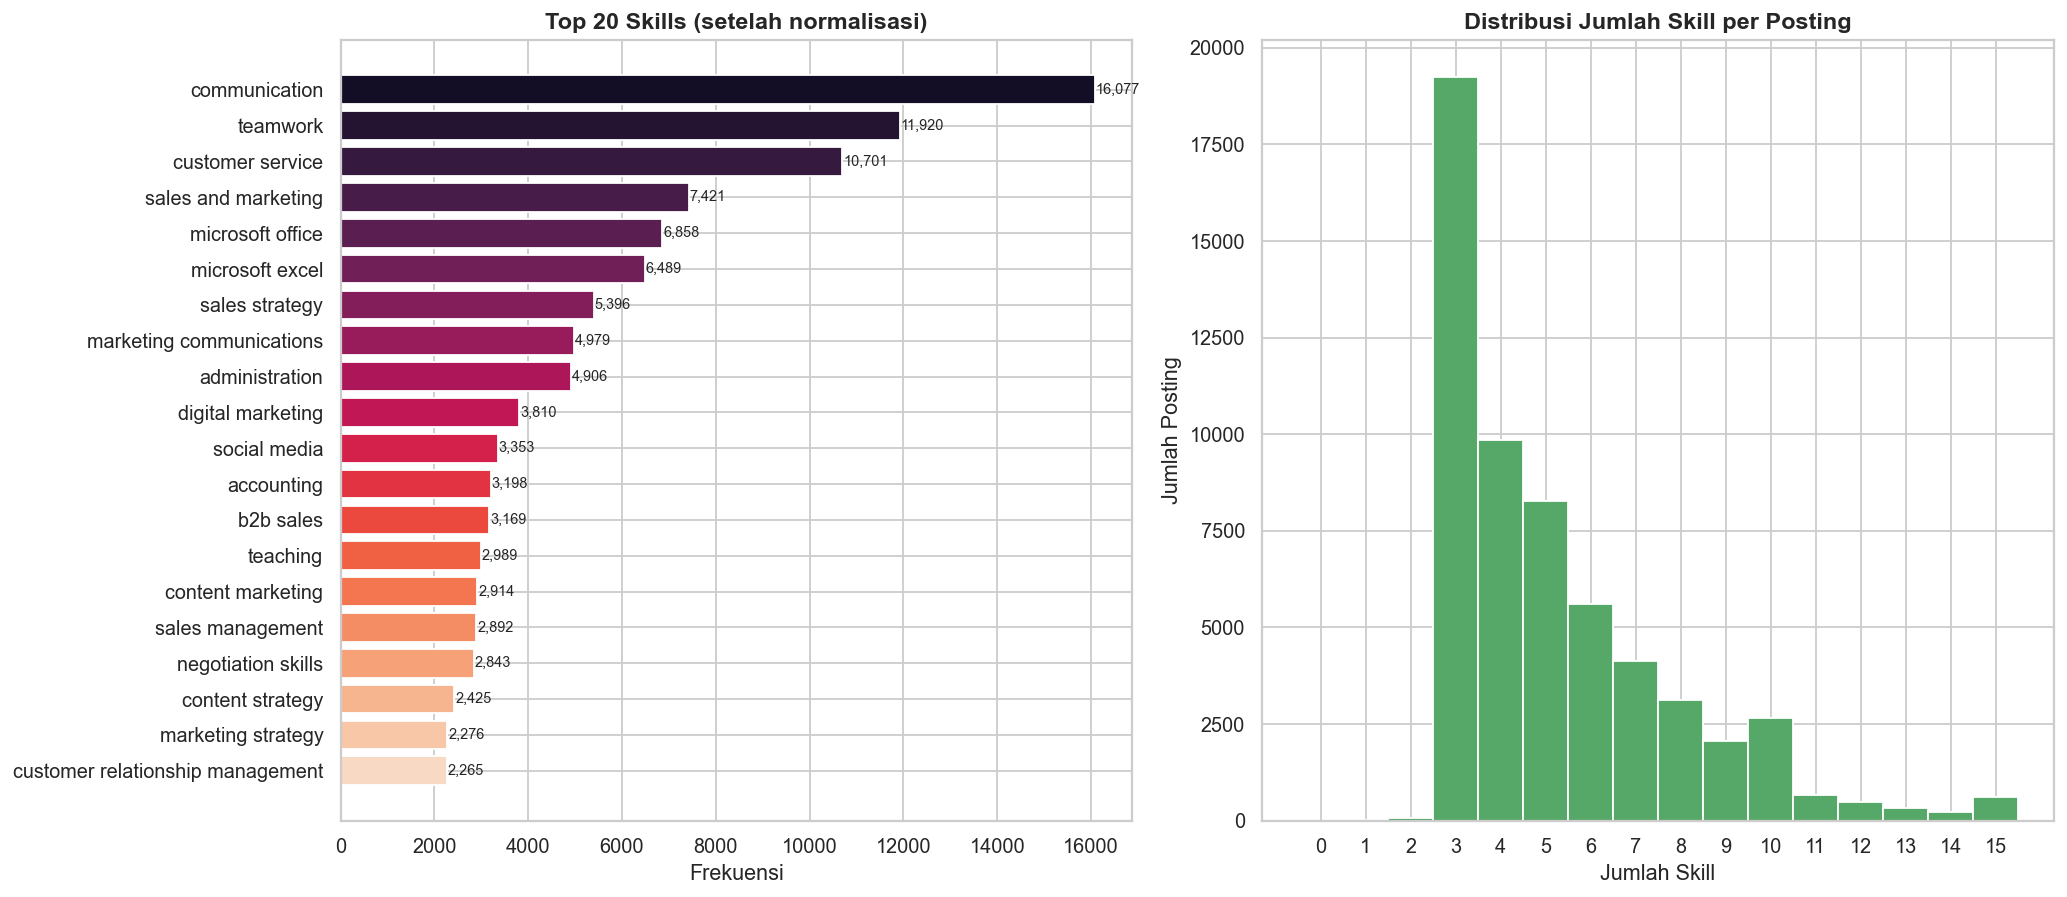

In [31]:
# ── Visualisasi Top Skills Setelah Normalisasi ──

# Menggunakan explode jauh lebih efisien untuk meratakan (flatten) kolom list di pandas
all_skills_norm = df["skills_list"].explode().dropna().tolist()

top30_skills = pd.DataFrame(
    Counter(all_skills_norm).most_common(30), columns=["skill", "freq"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Sub-plot Kiri: Top 20 skills
axes[0].barh(
    top30_skills["skill"][:20][::-1],
    top30_skills["freq"][:20][::-1],
    color=sns.color_palette("rocket_r", 20),
)
axes[0].set_title("Top 20 Skills (setelah normalisasi)")
axes[0].set_xlabel("Frekuensi")

# Menambahkan label angka di ujung barchart
for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width()):,}",
        va="center",
        fontsize=8,
    )

# 2. Sub-plot Kanan: Distribusi skill count per posting
# 👇 Solusi: Hitung panjang list on-the-fly dengan .apply(len) menggantikan 'skill_count'
skills_distribution = df["skills_list"].apply(len).clip(0, 15)

axes[1].hist(
    skills_distribution,
    bins=range(0, 17),
    color="#55A868",
    edgecolor="white",
    align="left",
)
axes[1].set_title("Distribusi Jumlah Skill per Posting")
axes[1].set_xlabel("Jumlah Skill")
axes[1].set_ylabel("Jumlah Posting")
axes[1].set_xticks(range(0, 16))

plt.tight_layout()
plt.show()

---
## 4. Preprocessing: SALARY

### 4.1 Konversi Semua Mode ke Bulanan

In [32]:
# ── Multiplier per Salary_Mode ──
MODE_MULTIPLIER = {
    'MONTH'  : 1,          # sudah bulanan
    'YEAR'   : 1 / 12,     # tahunan → bulanan
    'HOUR'   : 160,        # per jam × 160 jam/bulan (40 jam/minggu × 4 minggu)
    'DAY'    : 22,         # per hari × 22 hari kerja/bulan
    'WEEK'   : 4.33,       # per minggu × 4.33 minggu/bulan (52/12)
    'PROJECT': 1,          # asumsi tidak bisa dikonversi, 
}

def salary_to_monthly(value, mode):
    """
    Konversi nilai salary ke satuan bulanan berdasarkan Salary_Mode.
    Return NaN jika mode tidak dikenali atau value tidak valid.
    """
    if pd.isna(value) or pd.isna(mode):
        return np.nan
    multiplier = MODE_MULTIPLIER.get(str(mode).upper().strip(), None)
    if multiplier is None:      # PROJECT atau unknown
        return np.nan
    return float(value) * multiplier


print('✅ salary_to_monthly terdefinisi.')
print('\nDemonstrasi konversi:')
demos = [
    (5_000_000, 'MONTH', '5.000.000 MONTH → '),
    (60_000_000, 'YEAR',  '60.000.000 YEAR  → '),
    (50_000,   'DAY',   '50.000 DAY        → '),
    (25_000,   'HOUR',  '25.000 HOUR       → '),
    (800_000,  'WEEK',  '800.000 WEEK      → '),
]
for val, mode, label in demos:
    result = salary_to_monthly(val, mode)
    print(f'  {label} Rp {result:,.0f}/bulan')

✅ salary_to_monthly terdefinisi.

Demonstrasi konversi:
  5.000.000 MONTH →  Rp 5,000,000/bulan
  60.000.000 YEAR  →  Rp 5,000,000/bulan
  50.000 DAY        →  Rp 1,100,000/bulan
  25.000 HOUR       →  Rp 4,000,000/bulan
  800.000 WEEK      →  Rp 3,464,000/bulan


### 4.2 Terapkan Cleaning & Konversi

In [33]:
# ===============================
# 1. Convert to numeric
# ===============================
df[['Min_Salary','Max_Salary']] = (
    df[['Min_Salary','Max_Salary']]
    .apply(pd.to_numeric, errors='coerce')
)

# ===============================
# 2. Replace 0 -> NaN
# ===============================
df[['Min_Salary','Max_Salary']] = (
    df[['Min_Salary','Max_Salary']]
    .replace(0, np.nan)
)

# ===============================
# 3. Impute missing values (2 arah)
# ===============================
df['Max_Salary'] = df['Max_Salary'].fillna(df['Min_Salary'])
df['Min_Salary'] = df['Min_Salary'].fillna(df['Max_Salary'])

# ===============================
# 4. Salary mode conversion
# ===============================
MODE_MULT = {
    'MONTH'  : 1,
    'YEAR'   : 1/12,
    'HOUR'   : 160,
    'DAY'    : 22,
    'WEEK'   : 4.3,
    'PROJECT': 1,
}

df['multiplier'] = df['Salary_Mode'].map(MODE_MULT)

# ===============================
# 5. Convert to monthly (vectorized)
# ===============================
df['salary_min_monthly'] = df['Min_Salary'] * df['multiplier']
df['salary_max_monthly'] = df['Max_Salary'] * df['multiplier']

# ===============================
# 6. Valid salary flag
# ===============================
df['has_salary'] = df[['salary_min_monthly','salary_max_monthly']].notna().any(axis=1)

# ── Avg salary ──
df['salary_avg'] = (df['salary_min_monthly'] + df['salary_max_monthly']) / 2

# ===============================
# 7. Filter valid range (min <= max)
# ===============================
valid_df = df[df['salary_min_monthly'] <= df['salary_max_monthly']]

# ===============================
# 8. Summary
# ===============================
valid_count = len(valid_df)
total_count = len(df)



print(f'Baris dengan data salary valid : {valid_count:,} ({valid_count/total_count*100:.1f}%)')
print(f'Baris tanpa data salary        : {(~df["has_salary"]).sum():,}')
print()

print('salary_min_monthly stats (Juta Rp):')
print((df['salary_min_monthly'] / 1e6).describe().round(2))

Baris dengan data salary valid : 49,282 (85.9%)
Baris tanpa data salary        : 8,063

salary_min_monthly stats (Juta Rp):
count    49282.00
mean         3.66
std          3.49
min          0.00
25%          2.00
50%          3.00
75%          5.00
max        205.37
Name: salary_min_monthly, dtype: float64


### 4.3 Salary Tier Labeling

> **Tujuan untuk model:** Salary tier dapat digunakan sebagai *target label* untuk klasifikasi, atau sebagai fitur kategorik tambahan dalam model rekomendasi.

In [34]:
SALARY_BINS   = [0, 2_000_000, 5_000_000, 10_000_000, 20_000_000, float('inf')]
SALARY_LABELS = [
    'Rendah (<2 Jt)',
    'Menengah Bawah (2-5 Jt)',
    'Menengah (5-10 Jt)',
    'Menengah Atas (10-20 Jt)',
    'Tinggi (>20 Jt)',
]
SALARY_TIER_ENCODE = {
    'Rendah (<2 Jt)'          : 1,
    'Menengah Bawah (2-5 Jt)' : 2,
    'Menengah (5-10 Jt)'      : 3,
    'Menengah Atas (10-20 Jt)': 4,
    'Tinggi (>20 Jt)'         : 5,
}

df['salary_tier']        = pd.cut(df['salary_avg'], bins=SALARY_BINS,
                                   labels=SALARY_LABELS, right=True)
df['salary_tier_encoded'] = df['salary_tier'].map(SALARY_TIER_ENCODE)

print('Distribusi Salary Tier:')
tier_dist = df['salary_tier'].value_counts().sort_index()
print(pd.DataFrame({
    'Count'  : tier_dist,
    'Pct (%)': (tier_dist / len(df) * 100).round(1)
}).to_string())

Distribusi Salary Tier:
                          Count  Pct (%)
salary_tier                             
Rendah (<2 Jt)             9122     15.9
Menengah Bawah (2-5 Jt)   25740     44.9
Menengah (5-10 Jt)        12162     21.2
Menengah Atas (10-20 Jt)   1987      3.5
Tinggi (>20 Jt)             271      0.5


### 4.4 Min-Max Normalization untuk Fitur Numerik Model

> **Kenapa normalisasi?** Model NLP (cosine similarity, neural) sensitif terhadap skala. Salary dalam satuan jutaan akan mendominasi fitur teks jika tidak dinormalisasi ke rentang yang sama [0, 1].  
> **Strategi outlier:** Salary di atas persentil 99 di-cap sebelum scaling agar outlier ekstrem tidak mengecilkan semua nilai lainnya.

In [35]:
df_sal_valid = df[df['has_salary']].copy()

# ── Cap outlier di persentil 99 ──
p99 = df_sal_valid['salary_avg'].quantile(0.99)
print(f'Persentil 99 salary_avg : Rp {p99:,.0f} ({p99/1e6:.1f} Juta)')
print(f'Baris di atas P99       : {(df_sal_valid["salary_avg"] > p99).sum():,}')

df.loc[df['has_salary'], 'salary_avg_capped'] = df_sal_valid['salary_avg'].clip(upper=p99)

# ── Min-Max Scaling [0, 1] ──
scaler = MinMaxScaler(feature_range=(0, 1))
mask_sal = df['salary_avg_capped'].notna()
df.loc[mask_sal, 'salary_normalized'] = scaler.fit_transform(
    df.loc[mask_sal, 'salary_avg_capped'].values.reshape(-1, 1)
).flatten()

print()
print('Statistik salary_normalized [0–1]:')
print(df['salary_normalized'].describe().round(4))
print()
print('Contoh nilai:')
print(df[df['has_salary']][['salary_avg', 'salary_avg_capped', 'salary_normalized']]
      .rename(columns={'salary_avg':'avg_raw', 'salary_avg_capped':'avg_capped', 'salary_normalized':'normalized'})
      .head(8).assign(
          avg_raw=lambda x: (x['avg_raw']/1e6).round(2).astype(str) + ' Jt',
          avg_capped=lambda x: (x['avg_capped']/1e6).round(2).astype(str) + ' Jt',
          normalized=lambda x: x['normalized'].round(4)
      ).to_string())

Persentil 99 salary_avg : Rp 16,500,000 (16.5 Juta)
Baris di atas P99       : 486

Statistik salary_normalized [0–1]:
count    49282.0000
mean         0.2632
std          0.1716
min          0.0000
25%          0.1515
50%          0.2273
75%          0.3333
max          1.0000
Name: salary_normalized, dtype: float64

Contoh nilai:
   avg_raw avg_capped  normalized
0   6.0 Jt     6.0 Jt      0.3636
1  5.75 Jt    5.75 Jt      0.3485
2   0.2 Jt     0.2 Jt      0.0121
3   5.5 Jt     5.5 Jt      0.3333
4  1.15 Jt    1.15 Jt      0.0697
5   1.5 Jt     1.5 Jt      0.0909
6   8.0 Jt     8.0 Jt      0.4848
7  2.55 Jt    2.55 Jt      0.1545


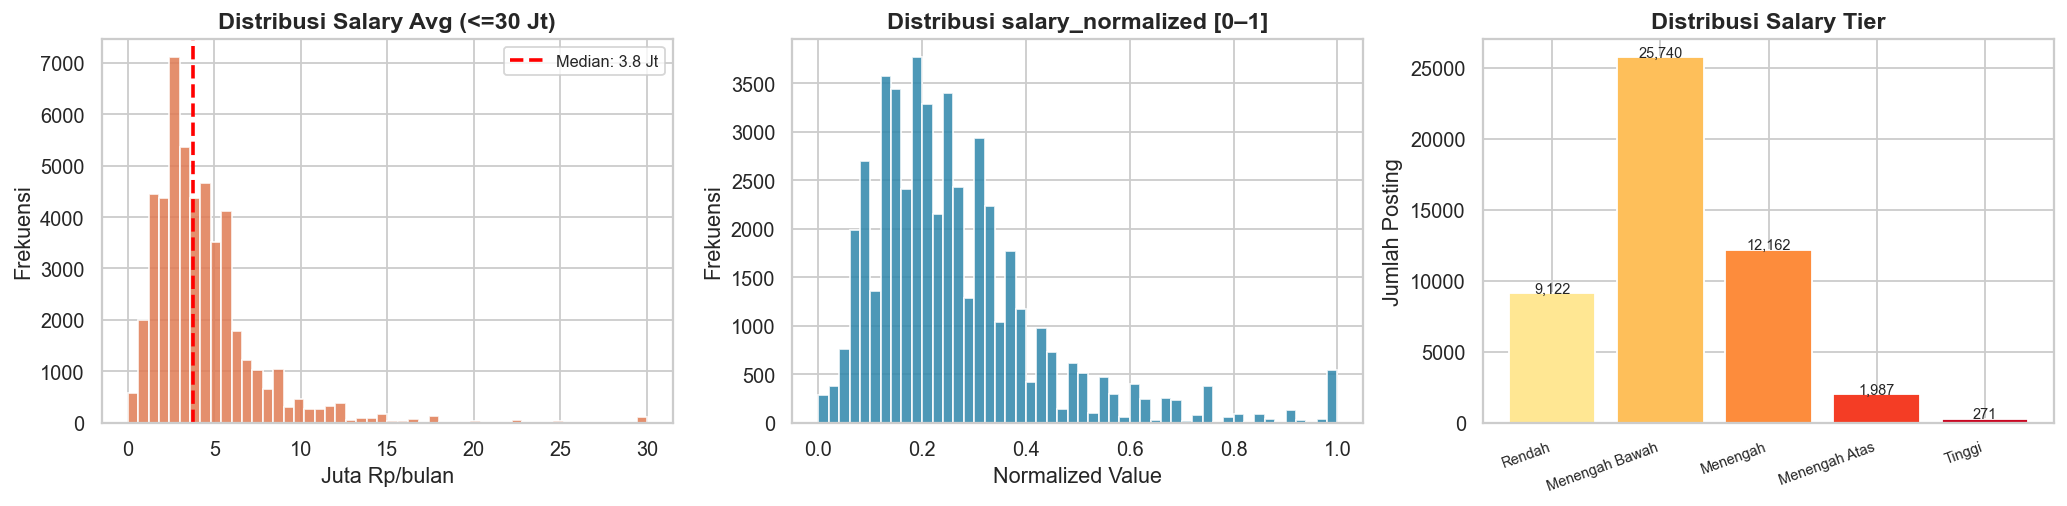

In [36]:
# ── Visualisasi Distribusi Salary ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw salary distribution (cap 30 Jt untuk viz)
sal_jt = (df.loc[df['has_salary'], 'salary_avg'] / 1e6).clip(upper=30)
axes[0].hist(sal_jt, bins=50, color='#E07B54', edgecolor='white', alpha=0.85)
axes[0].axvline(sal_jt.median(), color='red', linestyle='--', lw=2,
                label=f'Median: {sal_jt.median():.1f} Jt')
axes[0].set_title('Distribusi Salary Avg (<=30 Jt)')
axes[0].set_xlabel('Juta Rp/bulan')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

# Normalized salary distribution
axes[1].hist(df['salary_normalized'].dropna(), bins=50,
             color='#2E86AB', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi salary_normalized [0–1]')
axes[1].set_xlabel('Normalized Value')
axes[1].set_ylabel('Frekuensi')

# Salary Tier bar
tier = df['salary_tier'].value_counts().sort_index()
axes[2].bar(range(len(tier)), tier.values, color=sns.color_palette('YlOrRd', len(tier)))
axes[2].set_title('Distribusi Salary Tier')
axes[2].set_xticks(range(len(tier)))
axes[2].set_xticklabels([l.split('(')[0].strip() for l in tier.index],
                         rotation=20, ha='right', fontsize=8)
axes[2].set_ylabel('Jumlah Posting')
for i, v in enumerate(tier.values):
    axes[2].text(i, v + 50, f'{v:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

---
## 6. Quality Check — Full Preprocessing Report

In [37]:
print('=' * 60)
print('PREPROCESSING QUALITY REPORT')
print('=' * 60)

# ── SKILLS ──
print('\n[ SKILLS ]')
skills_before = df['Skills'].str.split(',').explode().str.strip().nunique()
all_skills_norm_check = [sk for lst in df['skills_list'] for sk in lst]
skills_after = len(set(all_skills_norm_check))
print(f'  Unique SEBELUM    : {skills_before:,}')
print(f'  Unique SESUDAH    : {skills_after:,}')
print(f'  Reduksi           : {skills_before - skills_after:,} ({(1-skills_after/skills_before)*100:.1f}%)')
print(f"  Posting 0 skill   : {(df['skills_list'].apply(len) == 0).sum():,}")

# ── SALARY ──
print('\n[ SALARY ]')
print(f'  Posting valid     : {df["has_salary"].sum():,} ({df["has_salary"].mean()*100:.1f}%)')
print(f'  Posting no-salary : {(~df["has_salary"]).sum():,}')
print(f'  Median avg salary : Rp {df["salary_avg"].median()/1e6:.2f} Juta/bulan')
print(f'  P99 salary (cap)  : Rp {p99/1e6:.1f} Juta/bulan')
print(f'  salary_normalized : [0 – {df["salary_normalized"].max():.4f}]')

print('\n' + '=' * 60)
print('Total baris final :', f'{len(df):,}')
print('Kolom NLP-ready    :', ['skills_list',
                                'salary_min_monthly','salary_max_monthly',
                                'salary_avg','salary_normalized','salary_tier',
                                'salary_tier_encoded','has_salary'])
print('=' * 60)

PREPROCESSING QUALITY REPORT

[ SKILLS ]
  Unique SEBELUM    : 9,635
  Unique SESUDAH    : 8,885
  Reduksi           : 750 (7.8%)
  Posting 0 skill   : 0

[ SALARY ]
  Posting valid     : 49,282 (85.9%)
  Posting no-salary : 8,063
  Median avg salary : Rp 3.75 Juta/bulan
  P99 salary (cap)  : Rp 16.5 Juta/bulan
  salary_normalized : [0 – 1.0000]

Total baris final : 57,345
Kolom NLP-ready    : ['skills_list', 'salary_min_monthly', 'salary_max_monthly', 'salary_avg', 'salary_normalized', 'salary_tier', 'salary_tier_encoded', 'has_salary']


---
## 7. Ringkasan Kolom Final & Schema untuk Model

In [38]:
print('Schema Kolom Output untuk Career Recommendation Model:')
print()
schema = {
    'IDENTITAS': {
        'Job_Link'      : 'URL unik lowongan (ID)',
        'Title'         : 'Judul asli (raw)',
        'Industry'      : 'Industri (L1)',
        'Job_Category_parent': 'Kategori pekerjaan (L2)',
        'Job_Category'  : 'Detail Kategori Pekerjaan (L3)',
    },
    'TITLE (PROCESSED)': {
        'title_clean'       : 'Judul setelah cleaning (Title Case, no emoji)',
        'title_tokens'      : 'List token lowercase (stopwords removed)',
        'title_token_count' : 'Jumlah token dalam title',
    },
    'SKILLS (PROCESSED)': {
        'Skills'       : 'Skills asli (raw)',
        'skills_list'  : 'List skill ternormalisasi (canonical)',
        'skills_clean' : 'Skills join string ternormalisasi',
        'skill_count'  : 'Jumlah skill per posting',
    },
    'SALARY (PROCESSED)': {
        'salary_min_monthly'  : 'Salary minimum dalam Rp/bulan',
        'salary_max_monthly'  : 'Salary maximum dalam Rp/bulan',
        'salary_avg'          : 'Rata-rata salary (Rp/bulan)',
        'salary_avg_capped'   : 'salary_avg di-cap di P99 (untuk scaling)',
        'salary_normalized'   : 'Salary ternormalisasi MinMax [0–1]',
        'salary_tier'         : 'Label tier gaji (kategorik)',
        'salary_tier_encoded' : 'Tier gaji dalam integer 1–5',
        'has_salary'          : 'Boolean: True jika ada data salary',
    },
    'NLP FEATURE': {
        'text_combined'    : 'Gabungan title tokens + skills (untuk TF-IDF/BERT)',
        'text_word_count'  : 'Jumlah kata di text_combined',
        'text_char_count'  : 'Jumlah karakter di text_combined',
    },
    'KONTEKS (untuk filter/rekomendasi)': {
        'Job_Type'         : 'Tipe kontrak kerja',
        'Work Arrangement' : 'Mode kerja (ONSITE/HYBRID/REMOTE)',
        'Education'        : 'Pendidikan minimum',
        'Experience'       : 'Pengalaman minimum (tahun)',
    },
}

for section, cols in schema.items():
    print(f'  [{section}]')
    for col, desc in cols.items():
        print(f'    {col:<26} : {desc}')
    print()

Schema Kolom Output untuk Career Recommendation Model:

  [IDENTITAS]
    Job_Link                   : URL unik lowongan (ID)
    Title                      : Judul asli (raw)
    Industry                   : Industri (L1)
    Job_Category_parent        : Kategori pekerjaan (L2)
    Job_Category               : Detail Kategori Pekerjaan (L3)

  [TITLE (PROCESSED)]
    title_clean                : Judul setelah cleaning (Title Case, no emoji)
    title_tokens               : List token lowercase (stopwords removed)
    title_token_count          : Jumlah token dalam title

  [SKILLS (PROCESSED)]
    Skills                     : Skills asli (raw)
    skills_list                : List skill ternormalisasi (canonical)
    skills_clean               : Skills join string ternormalisasi
    skill_count                : Jumlah skill per posting

  [SALARY (PROCESSED)]
    salary_min_monthly         : Salary minimum dalam Rp/bulan
    salary_max_monthly         : Salary maximum dalam Rp/bulan
 

---
## 8. Export Dataset NLP-Ready

In [39]:
EXPORT_COLS = [
    # Identitas
    'Job_Link', 'Job_Category_parent', 'Job_Category',
    # Skills processed
    'Skills', 'skills_list'
]

EXPORT_COLS = [c for c in EXPORT_COLS if c in df.columns]
df_out = df[EXPORT_COLS].copy()

# Simpan ke CSV
OUTPUT_PATH = "glints_nlp_ready.csv"
df_out.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Dataset NLP-ready tersimpan ke: {OUTPUT_PATH}')
print(f'   Shape : {df_out.shape[0]:,} baris × {df_out.shape[1]} kolom')
print()
print('Preview:')
df_out.head()

✅ Dataset NLP-ready tersimpan ke: glints_nlp_ready.csv
   Shape : 57,345 baris × 5 kolom

Preview:


,Job_Link,Job_Category_parent,Job_Category,Skills,skills_list
0,https://glints.com/id/opportunities/jobs/26fd8...,"Supply Chain, Logistics & Transportation",Taxi Driver,"Customer Service, Communication Skills, Driving","[customer service, communication, driving]"
1,https://glints.com/id/opportunities/jobs/d75a7...,"Supply Chain, Logistics & Transportation",Taxi Driver,"Driving, Driver Training, Customer Service","[driving, driver training, customer service]"
2,https://glints.com/id/opportunities/jobs/8431f...,Services Industry,Kitchen Staff,"Time Management, Home Cooking, Cook, Teamwork","[time management, home cooking, cook, teamwork]"
3,https://glints.com/id/opportunities/jobs/11204...,"Supply Chain, Logistics & Transportation",Taxi Driver,"Teamwork, Customer Service, Driving","[teamwork, customer service, driving]"
4,https://glints.com/id/opportunities/jobs/17888...,"Supply Chain, Logistics & Transportation",Taxi Driver,"Communication Skills, Customer Service, Driving","[communication, customer service, driving]"


---
# 3. Feature Engineering

### 3.1 `salary_avg` — Rata-rata Gaji Bulanan
> **Alasan:** Representasi tunggal gaji mempermudah ranking, korelasi, dan perbandingan antar kelompok tanpa bias Min atau Max.

In [40]:
df['salary_avg_jt'] = (df['salary_avg'] / 1_000_000).round(6)
print('salary_avg_jt (Juta Rp):')
print(df['salary_avg_jt'].describe().round(2))

salary_avg_jt (Juta Rp):
count    49282.00
mean         4.46
std          4.22
min          0.00
25%          2.50
50%          3.75
75%          5.50
max        205.37
Name: salary_avg_jt, dtype: float64


### 3.2 `experience_level` — Level Karir
> **Alasan:** Nilai diskret Experience (0,1,3,5,10) dikonversi ke label bermakna yang memungkinkan segmentasi analisis lebih komunikatif.

In [41]:
def map_exp_level(exp):
    if exp == 0:        return 'Entry Level (0 thn)'
    elif 1 <= exp <= 3: return 'Junior (1-3 thn)'
    elif 4 <= exp <= 6: return 'Mid Level (4-6 thn)'
    else:               return 'Senior (>6 thn)'

LEVEL_ORDER = ['Entry Level (0 thn)','Junior (1-3 thn)','Mid Level (4-6 thn)','Senior (>6 thn)']
df['experience_level'] = df['Experience'].apply(map_exp_level)

print('Distribusi experience_level:')
print(df['experience_level'].value_counts().reindex(LEVEL_ORDER).to_string())

Distribusi experience_level:
experience_level
Entry Level (0 thn)    19249
Junior (1-3 thn)       35849
Mid Level (4-6 thn)     2094
Senior (>6 thn)          153


### 3.4 Fitur Tambahan

> - **`salary_range_width_jt`**: Selisih Max–Min salary → indikator negosiabilitas gaji  
> - **`salary_tier`**: Bucket gaji → memudahkan segmentasi pasar  
> - **`education_rank`**: Ordinal pendidikan → korelasi numerik  
> - **`skill_count`**: Jumlah skill → proxy kompleksitas posisi  
> - **Label kolom**: Versi readable untuk visualisasi

In [42]:
df['salary_range_width_jt'] = ((df['salary_max_monthly'] - df['salary_min_monthly']) / 1e6).round(3)

bins_t   = [0, 2e6, 5e6, 10e6, 20e6, float('inf')]
labels_t = ['< 2 Jt','2-5 Jt','5-10 Jt','10-20 Jt','> 20 Jt']
df['salary_tier'] = pd.cut(df['salary_avg'], bins=bins_t, labels=labels_t)

EDU_RANK  = {'PRIMARY_SCHOOL':1,'SECONDARY_SCHOOL':2,'HIGH_SCHOOL':3,
             'DIPLOMA':4,'BACHELOR_DEGREE':5,'PROFESSIONAL_EDUCATION':5,
             'MASTER_DEGREE':6,'DOCTORATE':7}
EDU_LABEL = {'PRIMARY_SCHOOL':'SD','SECONDARY_SCHOOL':'SMP','HIGH_SCHOOL':'SMA/SMK',
             'DIPLOMA':'Diploma','BACHELOR_DEGREE':'S1','PROFESSIONAL_EDUCATION':'Profesional',
             'MASTER_DEGREE':'S2','DOCTORATE':'S3'}
JT_LABEL  = {'FULL_TIME':'Full Time','CONTRACT':'Kontrak','INTERNSHIP':'Magang',
             'PART_TIME':'Part Time','PROJECT_BASED':'Project Based'}
WA_LABEL  = {'ONSITE':'Onsite','HYBRID':'Hybrid','REMOTE':'Remote'}

df['education_rank']  = df['Education'].map(EDU_RANK)
df['Education_Label'] = df['Education'].map(EDU_LABEL)
df['Job_Type_Label']  = df['Job_Type'].map(JT_LABEL).fillna(df['Job_Type'])
df['Work_Arr_Label']  = df['Work Arrangement'].map(WA_LABEL).fillna(df['Work Arrangement'])
df['skill_count']     = df['Skills'].dropna().str.split(',').apply(len)
df['skill_count'].fillna(0, inplace=True)
df['skill_count']     = df['skill_count'].astype(int)

print('Kolom baru yang dibuat:')
new_cols = ['salary_avg','salary_avg_jt','salary_min_monthly','salary_max_monthly',
            'has_salary','salary_range_width_jt','salary_tier','experience_level',
            'Job_Category_parent','education_rank','Education_Label','Job_Type_Label',
            'Work_Arr_Label','skill_count']
for c in new_cols:
    print(f'  + {c}')
print(f'\nTotal kolom: {df.shape[1]}')

Kolom baru yang dibuat:
  + salary_avg
  + salary_avg_jt
  + salary_min_monthly
  + salary_max_monthly
  + has_salary
  + salary_range_width_jt
  + salary_tier
  + experience_level
  + Job_Category_parent
  + education_rank
  + Education_Label
  + Job_Type_Label
  + Work_Arr_Label
  + skill_count

Total kolom: 31


---
## 4. Exploratory Data Analysis (EDA)

### A. Job Market Insight

#### A.1 Top Industry & Job Cluster

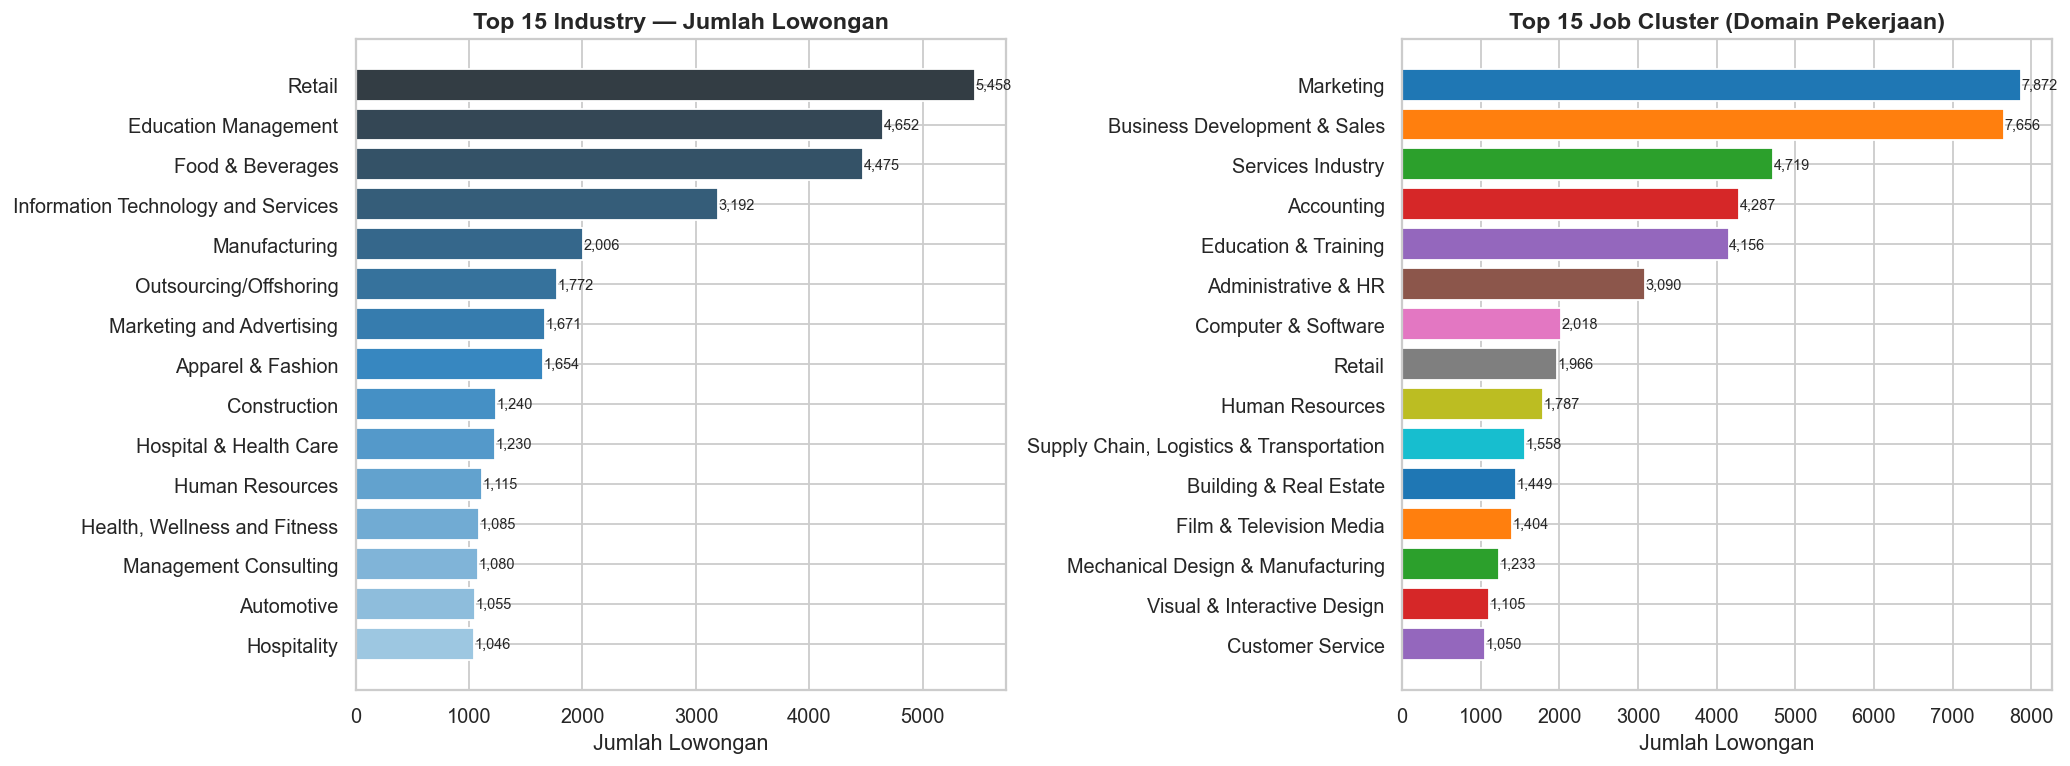

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ===============================
# 1. Top 15 Industry
# ===============================
top_ind = df['Industry'].value_counts().head(15)

axes[0].barh(top_ind.index[::-1], top_ind.values[::-1],
             color=sns.color_palette('Blues_d', 15))
axes[0].set_title('Top 15 Industry — Jumlah Lowongan')
axes[0].set_xlabel('Jumlah Lowongan')

for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 5,
                 bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}',
                 va='center', fontsize=8)

# ===============================
# 2. Top 15 Job Category Parent
# ===============================
top_cluster = df['Job_Category_parent'].value_counts().head(15)

axes[1].barh(top_cluster.index[::-1], top_cluster.values[::-1],
             color=sns.color_palette('tab10', 15)[::-1])
axes[1].set_title('Top 15 Job Cluster (Domain Pekerjaan)')
axes[1].set_xlabel('Jumlah Lowongan')

for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 5,
                 bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}',
                 va='center', fontsize=8)

plt.tight_layout()
plt.show()

#### A.2 Top 20 Job Category Paling Demand

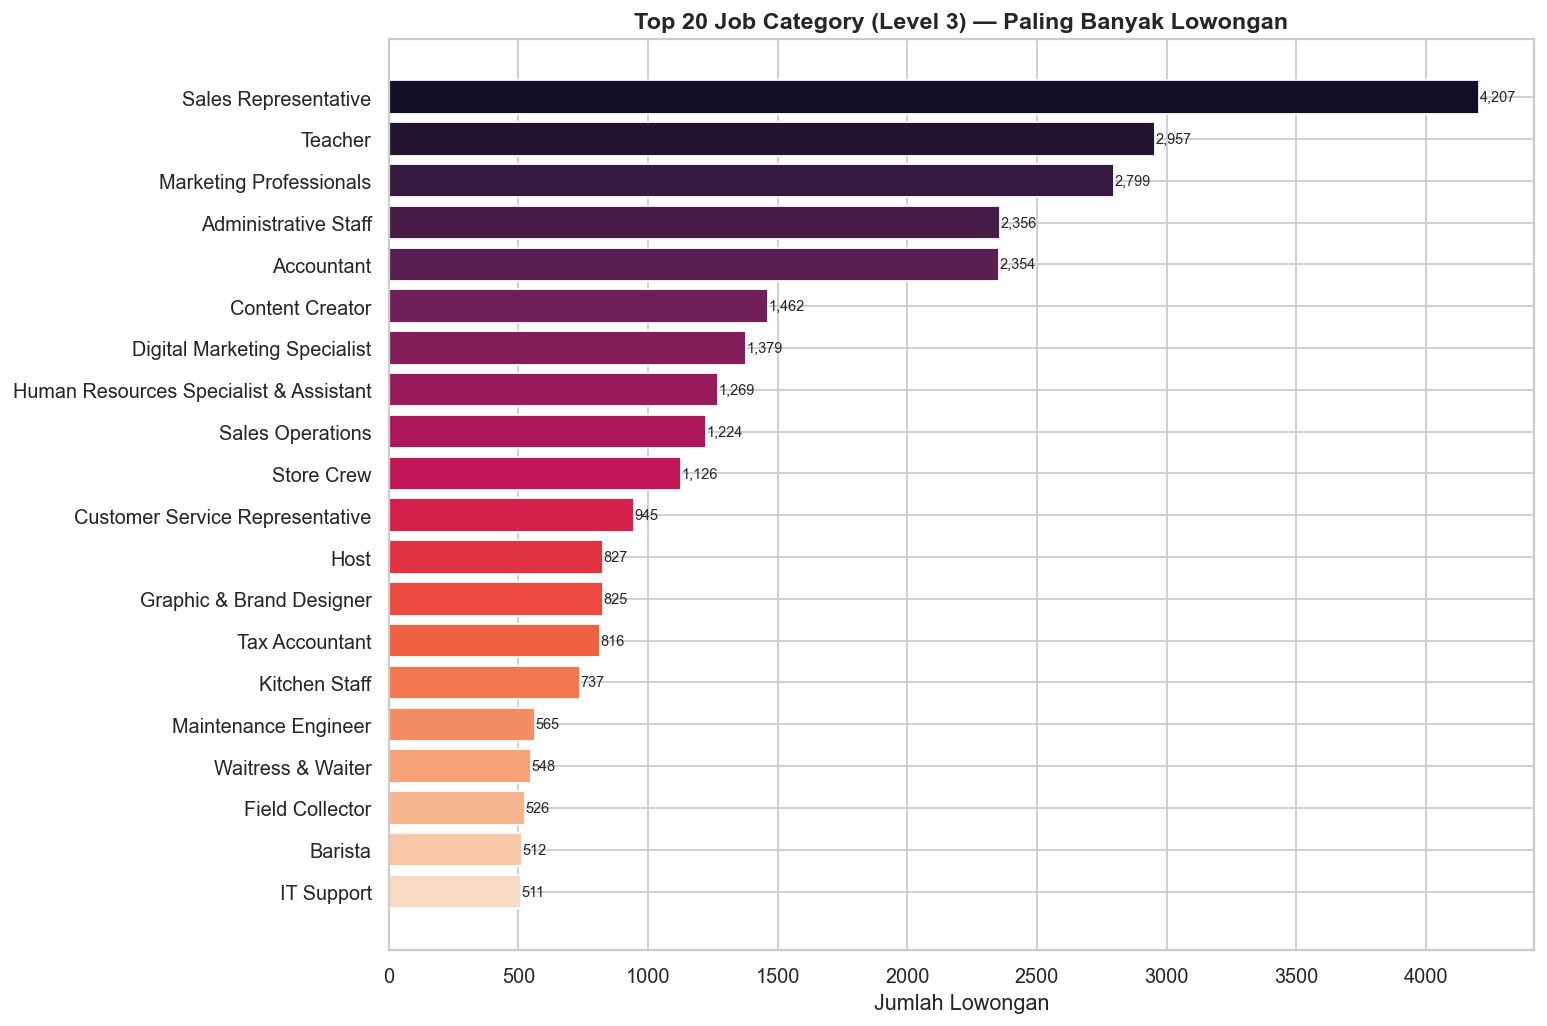

In [44]:
fig, ax = plt.subplots(figsize=(12, 8))
top_cat = df['Job_Category'].value_counts().head(20)
bars = ax.barh(top_cat.index[::-1], top_cat.values[::-1],
               color=sns.color_palette('rocket_r', 20))
ax.set_title('Top 20 Job Category (Level 3) — Paling Banyak Lowongan')
ax.set_xlabel('Jumlah Lowongan')
for bar in bars:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

#### A.3 Distribusi Job Type, Work Arrangement & Experience Level

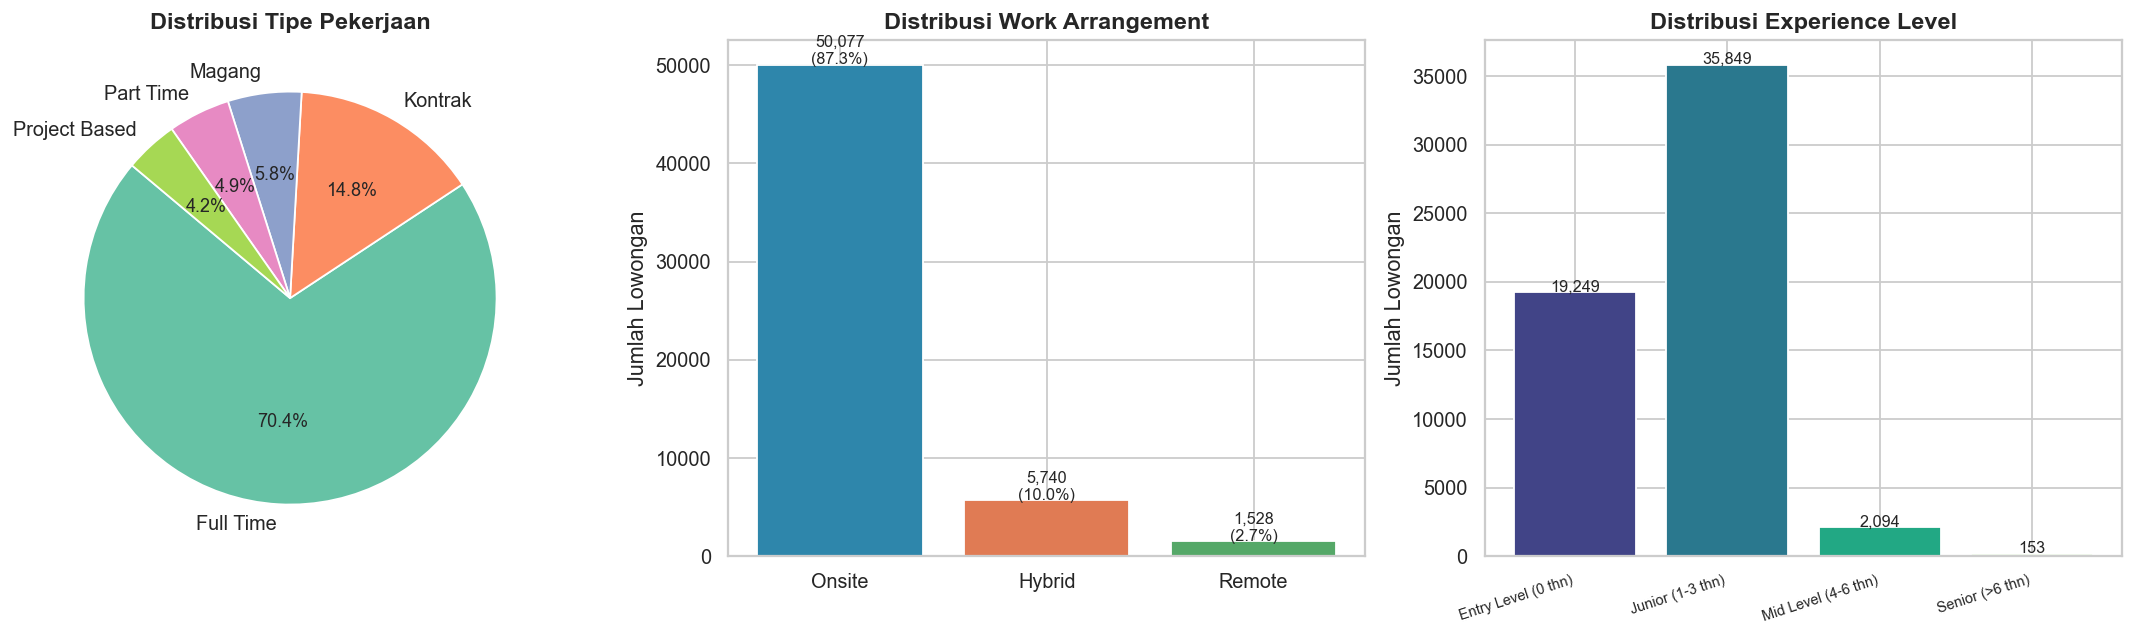

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

jt = df['Job_Type_Label'].value_counts()
axes[0].pie(jt, labels=jt.index, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', len(jt)))
axes[0].set_title('Distribusi Tipe Pekerjaan')

wa = df['Work_Arr_Label'].value_counts()
axes[1].bar(wa.index, wa.values, color=[BLUE, ORANGE, GREEN][:len(wa)])
axes[1].set_title('Distribusi Work Arrangement')
axes[1].set_ylabel('Jumlah Lowongan')
for i, v in enumerate(wa.values):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

el = df['experience_level'].value_counts().reindex(LEVEL_ORDER)
axes[2].bar(range(len(el)), el.values, color=sns.color_palette('viridis', 4))
axes[2].set_xticks(range(len(el)))
axes[2].set_xticklabels(LEVEL_ORDER, rotation=18, ha='right', fontsize=8)
axes[2].set_title('Distribusi Experience Level')
axes[2].set_ylabel('Jumlah Lowongan')
for i, v in enumerate(el.values):
    axes[2].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

#### A.4 Work Arrangement per Job Cluster — Siapa yang Paling Remote-Friendly?

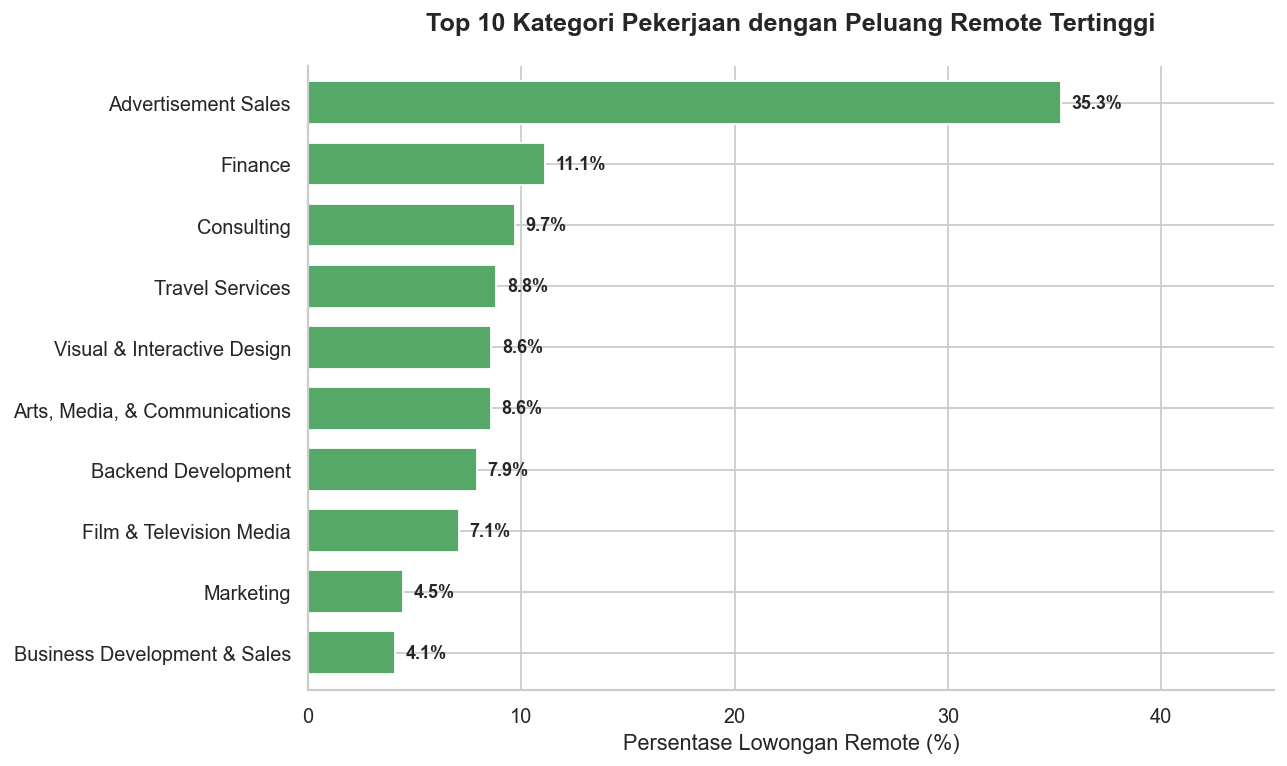

In [46]:
wa_cluster = (df.groupby(['Job_Category_parent','Work_Arr_Label']).size().unstack(fill_value=0))
wa_pct = wa_cluster.div(wa_cluster.sum(axis=1), axis=0) * 100

# 1. Filter hanya kolom 'Remote' dan ambil 10 besar
remote_top10 = wa_pct['Remote'].sort_values(ascending=False).head(10)

# 2. Plotting (menggunakan bar horizontal agar nama kategori terbaca jelas)
fig, ax = plt.subplots(figsize=(10, 6))

# Kita balik urutannya (sort_values() default) agar yang tertinggi ada di posisi paling atas pada chart
remote_top10.sort_values(ascending=True).plot(
    kind='barh', 
    color='#55A868', 
    ax=ax, 
    width=0.7
)

# 3. Tambahkan label angka di ujung bar agar data presisi
for i, v in enumerate(remote_top10.sort_values(ascending=True)):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=10)

# 4. Estetika
ax.set_title('Top 10 Kategori Pekerjaan dengan Peluang Remote Tertinggi', fontsize=14, pad=20)
ax.set_xlabel('Persentase Lowongan Remote (%)')
ax.set_ylabel('') # Nama kategori sudah jelas di sumbu Y
ax.set_xlim(0, max(remote_top10) + 10) # Beri ruang ekstra untuk label teks

# Menghilangkan garis tepi yang tidak perlu
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### A.5 Komposisi Hierarki: Top 8 Industry × Top Job Category Parent

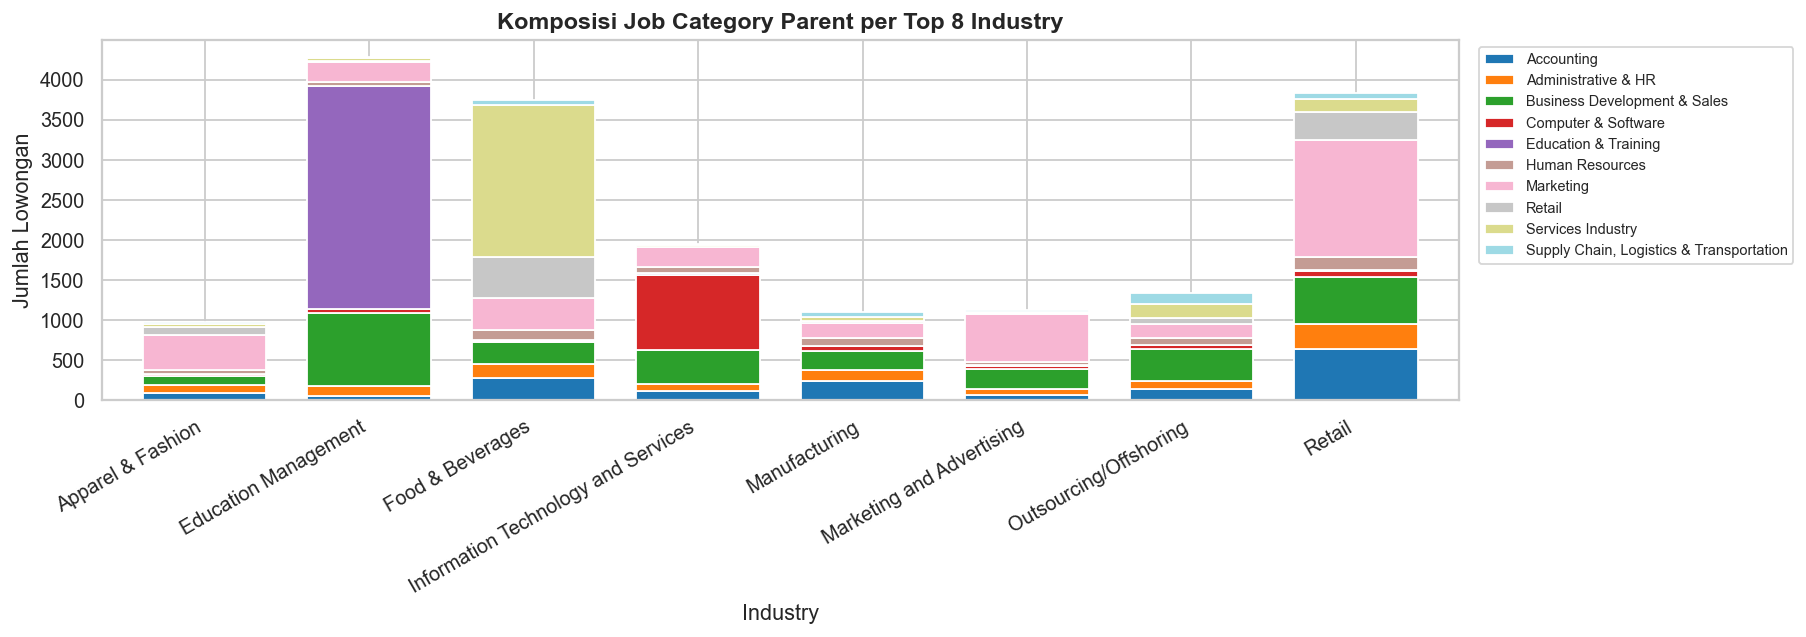

In [47]:
top8_ind    = df['Industry'].value_counts().head(8).index
top10_par   = df['Job_Category_parent'].value_counts().head(10).index
pivot_h = (
    df[df['Industry'].isin(top8_ind)]
    .groupby(['Industry','Job_Category_parent']).size().unstack(fill_value=0)
)
pivot_h = pivot_h[pivot_h.columns.intersection(top10_par)]

fig, ax = plt.subplots(figsize=(14, 5))
pivot_h.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.75)
ax.set_title('Komposisi Job Category Parent per Top 8 Industry')
ax.set_ylabel('Jumlah Lowongan')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
### B. Salary Analysis

#### B.1 Distribusi Salary Keseluruhan

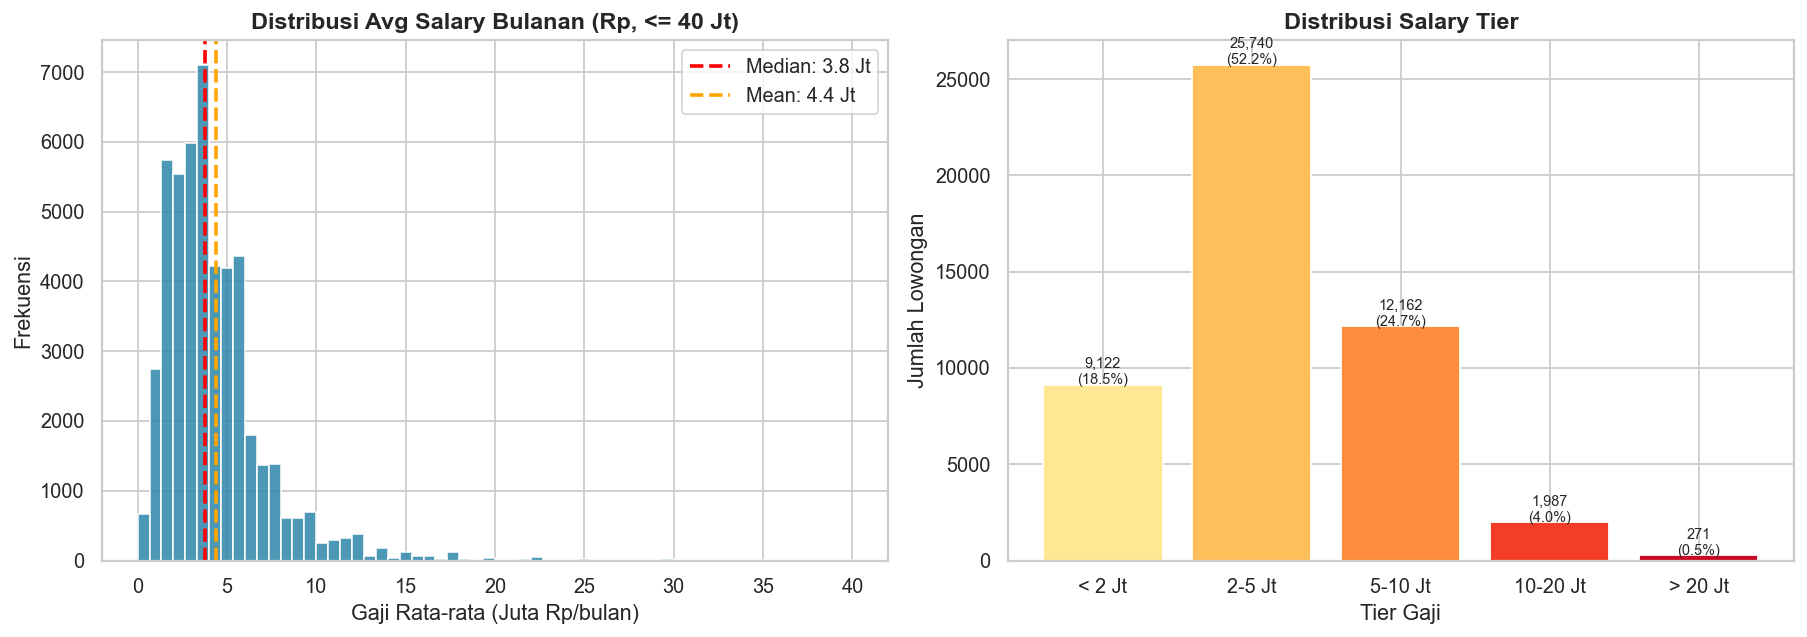

In [48]:
df_sal = df[df['has_salary']].copy()
df_viz = df_sal[df_sal['salary_avg_jt'] <= 40]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_viz['salary_avg_jt'], bins=60, color=BLUE, edgecolor='white', alpha=0.85)
med = df_viz['salary_avg_jt'].median()
mn  = df_viz['salary_avg_jt'].mean()
axes[0].axvline(med, color='red',    linestyle='--', lw=2, label=f'Median: {med:.1f} Jt')
axes[0].axvline(mn,  color='orange', linestyle='--', lw=2, label=f'Mean: {mn:.1f} Jt')
axes[0].set_title('Distribusi Avg Salary Bulanan (Rp, <= 40 Jt)')
axes[0].set_xlabel('Gaji Rata-rata (Juta Rp/bulan)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

tier = df_sal['salary_tier'].value_counts().sort_index()
axes[1].bar(tier.index, tier.values, color=sns.color_palette('YlOrRd', len(tier)))
axes[1].set_title('Distribusi Salary Tier')
axes[1].set_xlabel('Tier Gaji')
axes[1].set_ylabel('Jumlah Lowongan')
for i, v in enumerate(tier.values):
    axes[1].text(i, v + 30, f'{v:,}\n({v/len(df_sal)*100:.1f}%)', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

#### B.2 Rata-rata Salary per Industry (Top 10 by Median)

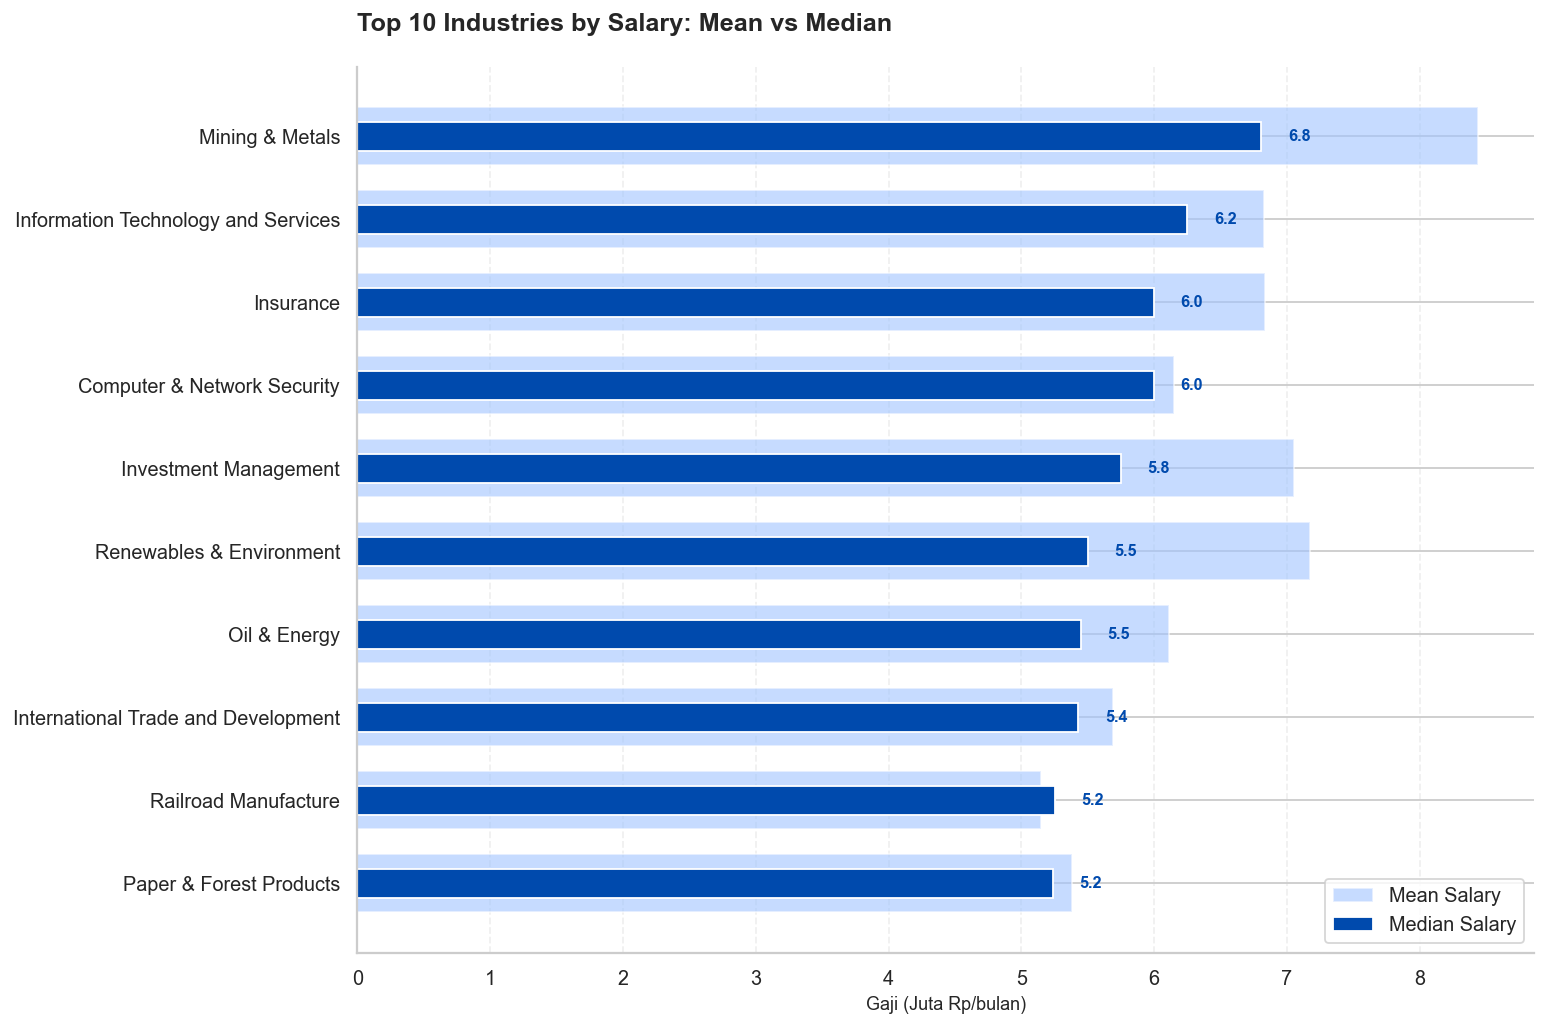

Top 10 Industry by Median Salary (Juta Rp):
                                     median  mean  count
Industry                                                
Mining & Metals                        6.81  8.44    134
Information Technology and Services    6.25  6.83   2712
Computer & Network Security            6.00  6.15    114
Insurance                              6.00  6.83    162
Investment Management                  5.75  7.05     42
Renewables & Environment               5.50  7.17     60
Oil & Energy                           5.45  6.11    190
International Trade and Development    5.43  5.69     39
Railroad Manufacture                   5.25  5.15     33
Paper & Forest Products                5.24  5.38     73


In [49]:
# Data sudah diproses di sal_ind (berdasarkan code snippet kamu)
# Kita urutkan ulang agar industri dengan gaji tertinggi berada di paling atas
sal_ind = (
    df_sal.groupby('Industry')['salary_avg_jt']
    .agg(median='median', mean='mean', count='count')
    .query('count >= 30').sort_values('median', ascending=False).head(10)
)
sal_ind_sorted = sal_ind.sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

# 1. Plot Mean (Bar yang lebih lebar/tebal di belakang)
ax.barh(sal_ind_sorted.index, sal_ind_sorted['mean'], 
        color='#A0C4FF', label='Mean Salary', alpha=0.6, height=0.7)

# 2. Plot Median (Bar yang lebih tipis di depan/dalam mean)
ax.barh(sal_ind_sorted.index, sal_ind_sorted['median'], 
        color='#004AAD', label='Median Salary', height=0.35)

# 3. Menambahkan label angka di ujung bar Median untuk presisi
for i, (idx, row) in enumerate(sal_ind_sorted.iterrows()):
    ax.text(row['median'] + 0.2, i, f"{row['median']:.1f}", 
            va='center', fontsize=9, fontweight='bold', color='#004AAD')

# 4. Estetika dan Styling
ax.set_title('Top 10 Industries by Salary: Mean vs Median', 
             loc='left', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Gaji (Juta Rp/bulan)', fontsize=10)
ax.legend(loc='lower right', frameon=True)

# Menghapus garis bingkai atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tambahkan grid halus pada sumbu X
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print('Top 10 Industry by Median Salary (Juta Rp):')
print(sal_ind.round(2).to_string())

#### B.3 Salary per Job_Category_parent & Job Cluster

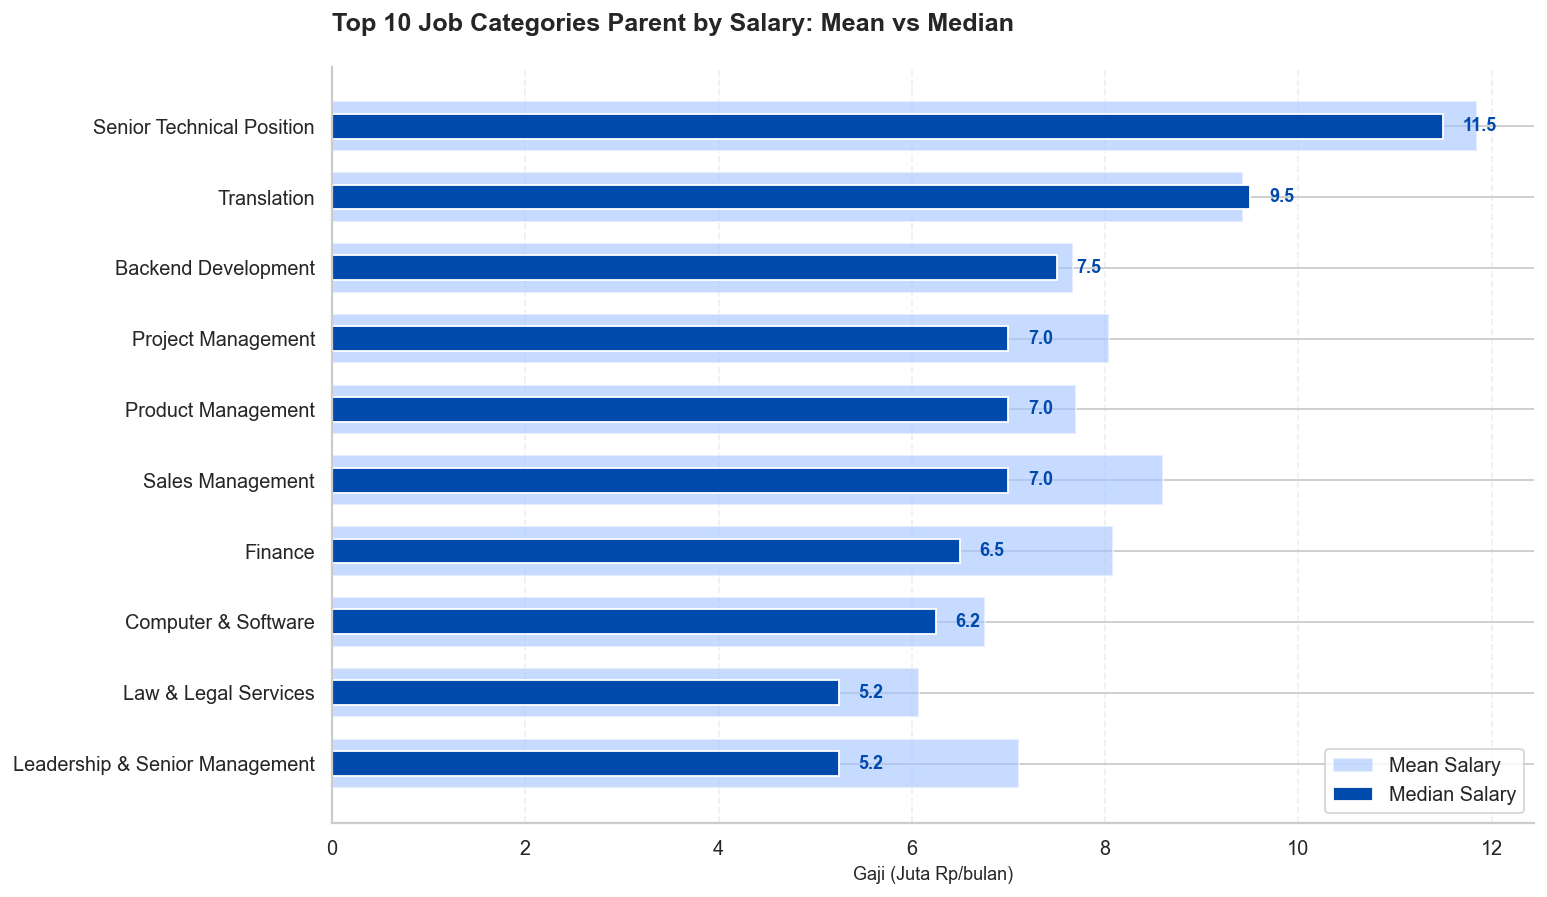

Top 10 Job Categories Parent by Median Salary (Juta Rp):
                                median   mean  count
Job_Category_parent                                 
Senior Technical Position        11.50  11.85     36
Translation                       9.50   9.43    305
Backend Development               7.50   7.67    711
Sales Management                  7.00   8.60    413
Product Management                7.00   7.70    275
Project Management                7.00   8.04    409
Finance                           6.50   8.08     21
Computer & Software               6.25   6.76   1649
Leadership & Senior Management    5.25   7.11    327
Law & Legal Services              5.25   6.07    215


In [50]:
# 1. Menyiapkan data Job Category Parent (Top 10)
sal_cat = (
    df_sal.groupby('Job_Category_parent')['salary_avg_jt']
    .agg(median='median', mean='mean', count='count')
    .query('count >= 20') # Minimal 20 data agar representatif
    .sort_values('median', ascending=False)
    .head(10)
)

# 2. Urutkan balik agar yang tertinggi berada di atas pada horizontal bar
sal_cat_sorted = sal_cat.sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

# 3. Plot Mean (Bar belakang - Lebar & Transparan)
ax.barh(sal_cat_sorted.index, sal_cat_sorted['mean'], 
        color='#A0C4FF', label='Mean Salary', alpha=0.6, height=0.7)

# 4. Plot Median (Bar depan - Tipis & Solid)
ax.barh(sal_cat_sorted.index, sal_cat_sorted['median'], 
        color='#004AAD', label='Median Salary', height=0.35)

# 5. Menambahkan label angka di ujung bar Median
for i, (idx, row) in enumerate(sal_cat_sorted.iterrows()):
    ax.text(row['median'] + 0.2, i, f"{row['median']:.1f}", 
            va='center', fontsize=10, fontweight='bold', color='#004AAD')

# 6. Estetika dan Styling
ax.set_title('Top 10 Job Categories Parent by Salary: Mean vs Median', 
             loc='left', fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Gaji (Juta Rp/bulan)', fontsize=10)
ax.legend(loc='lower right', frameon=True)

# Menghapus garis bingkai atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Tambahkan grid halus pada sumbu X
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print('Top 10 Job Categories Parent by Median Salary (Juta Rp):')
print(sal_cat.round(2).to_string())

#### B.4 Salary per Job Type — Box Plot

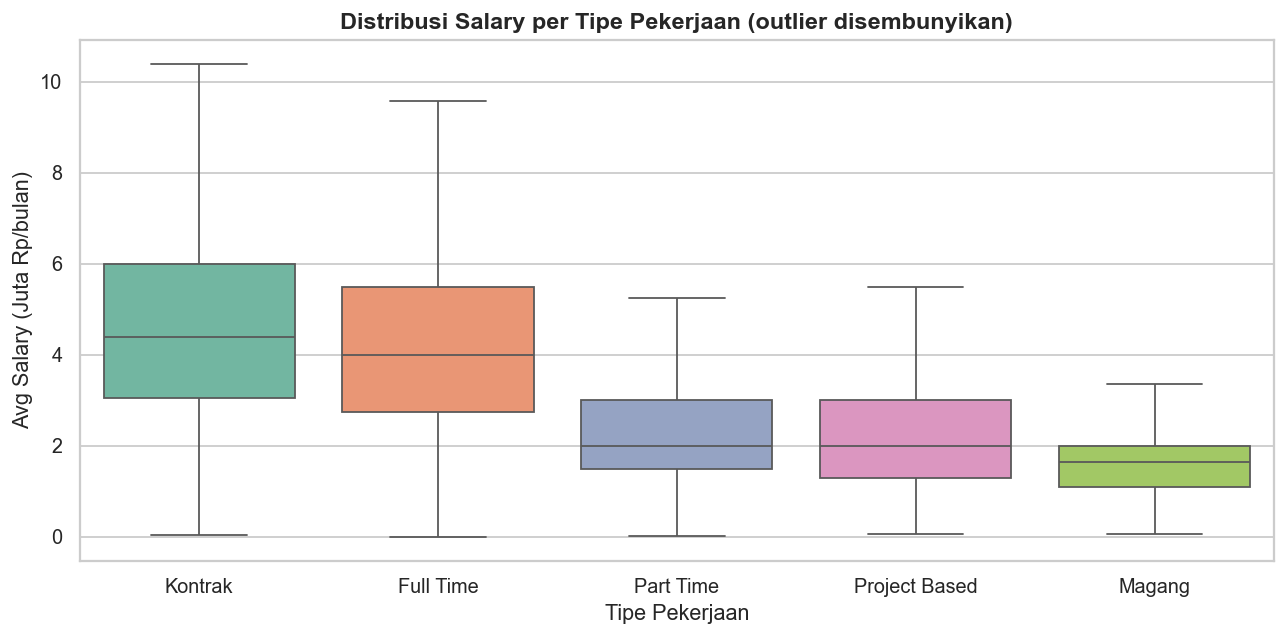

In [51]:
jt_order = df_sal.groupby('Job_Type_Label')['salary_avg_jt'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_sal[df_sal['salary_avg_jt'] <= 30],
            x='Job_Type_Label', y='salary_avg_jt',
            order=jt_order, palette='Set2', ax=ax, showfliers=False)
ax.set_title('Distribusi Salary per Tipe Pekerjaan (outlier disembunyikan)')
ax.set_xlabel('Tipe Pekerjaan')
ax.set_ylabel('Avg Salary (Juta Rp/bulan)')
plt.tight_layout()
plt.show()

#### B.5 Top 10 Job Category dengan Salary Tertinggi

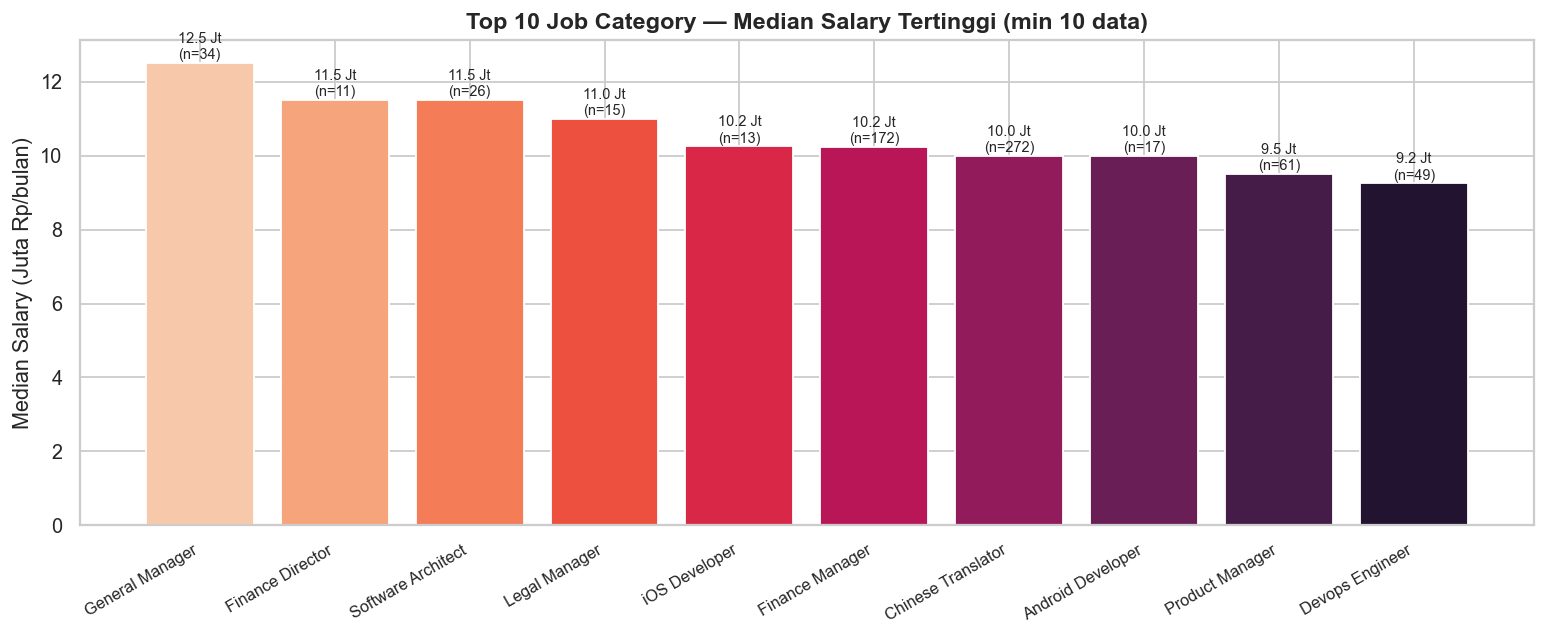

In [52]:
top10_sal = (
    df_sal.groupby('Job_Category')['salary_avg_jt']
    .agg(median='median', count='count').query('count >= 10')
    .sort_values('median', ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(top10_sal)), top10_sal['median'],
              color=sns.color_palette('rocket_r', 10))
ax.set_xticks(range(len(top10_sal)))
ax.set_xticklabels(top10_sal.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Median Salary (Juta Rp/bulan)')
ax.set_title('Top 10 Job Category — Median Salary Tertinggi (min 10 data)')
for i, (bar, (_, row)) in enumerate(zip(bars, top10_sal.iterrows())):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f} Jt\n(n={int(row["count"])})',
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

#### B.6 Bubble Chart: Demand vs Salary per Job Cluster

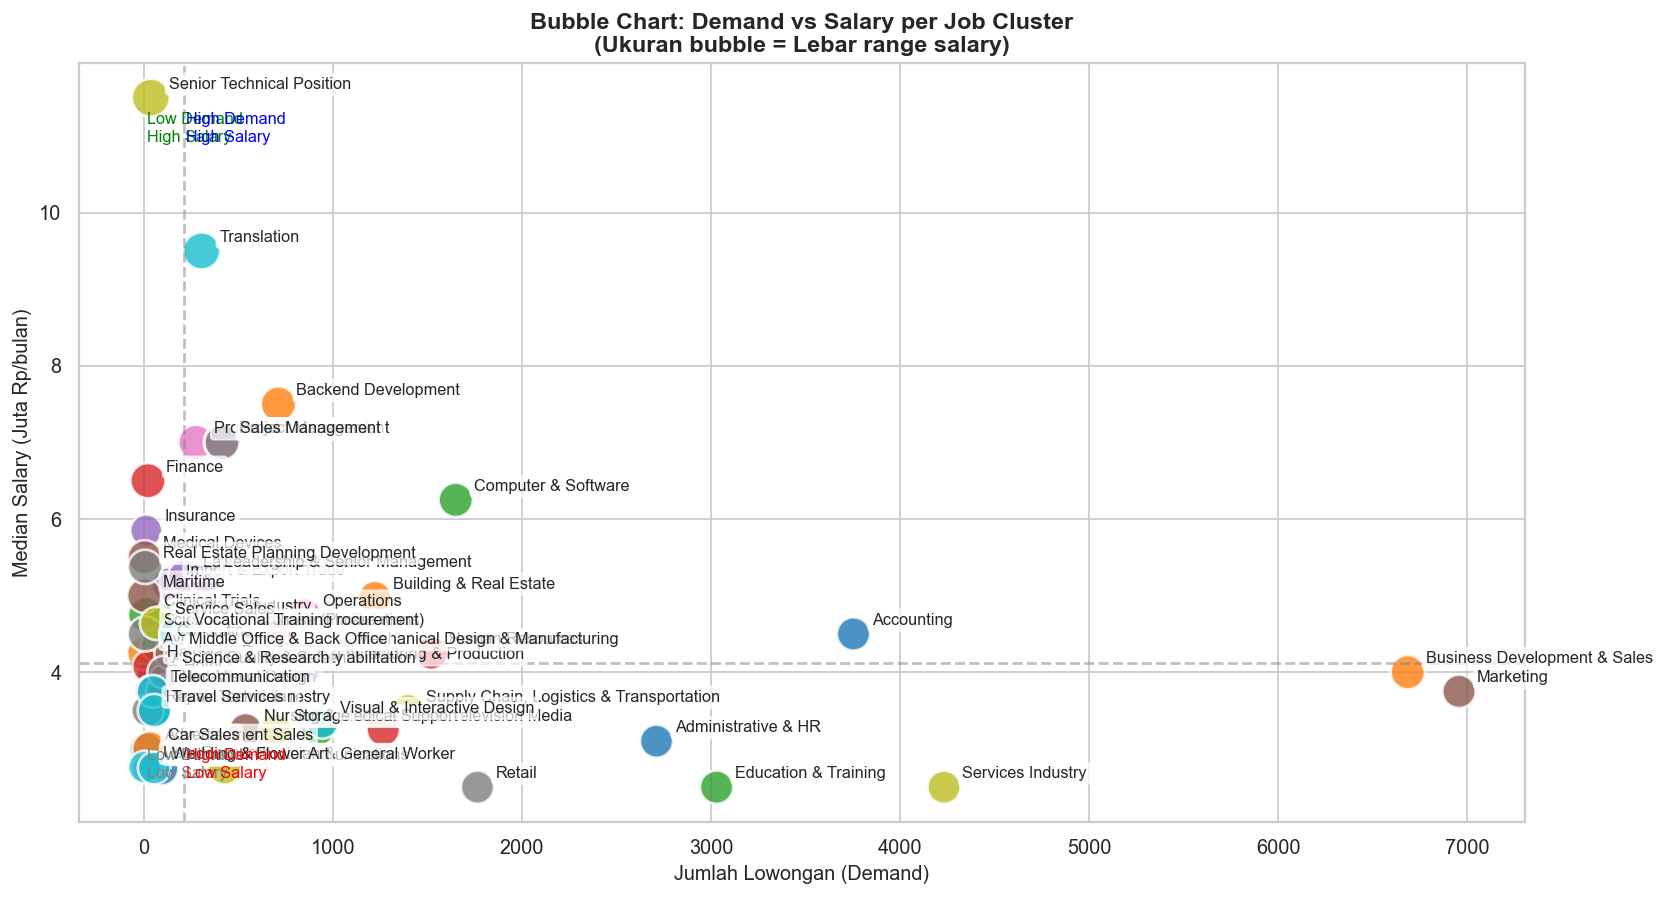

In [53]:
bubble = df_sal.groupby('Job_Category_parent').agg(
    count=('salary_avg_jt','count'),
    median_sal=('salary_avg_jt','median'),
    range_w=('salary_range_width_jt','median')
).reset_index()

med_x = bubble['count'].median()
med_y = bubble['median_sal'].median()

fig, ax = plt.subplots(figsize=(13, 7))
ax.scatter(bubble['count'], bubble['median_sal'],
           s=(bubble['range_w'].fillna(0) * 40 + 300),
           c=range(len(bubble)), cmap='tab10', alpha=0.8,
           edgecolors='white', linewidths=1.5)
for _, r in bubble.iterrows():
    ax.annotate(r['Job_Category_parent'], (r['count'], r['median_sal']),
                textcoords='offset points', xytext=(10,5), fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.axvline(med_x, color='gray', linestyle='--', alpha=0.5)
ax.axhline(med_y, color='gray', linestyle='--', alpha=0.5)
ax.text(med_x*0.08, bubble['median_sal'].max()*0.95, 'Low Demand\nHigh Salary', color='green', fontsize=9)
ax.text(med_x*1.05, bubble['median_sal'].max()*0.95, 'High Demand\nHigh Salary', color='blue',  fontsize=9)
ax.text(med_x*0.08, bubble['median_sal'].min()*1.05, 'Low Demand\nLow Salary',  color='gray',  fontsize=9)
ax.text(med_x*1.05, bubble['median_sal'].min()*1.05, 'High Demand\nLow Salary', color='red',   fontsize=9)
ax.set_xlabel('Jumlah Lowongan (Demand)', fontsize=11)
ax.set_ylabel('Median Salary (Juta Rp/bulan)', fontsize=11)
ax.set_title('Bubble Chart: Demand vs Salary per Job Cluster\n(Ukuran bubble = Lebar range salary)')
plt.tight_layout()
plt.show()

---
### C. Skill Analysis

#### C.1 Top 25 Skills Paling Dibutuhkan

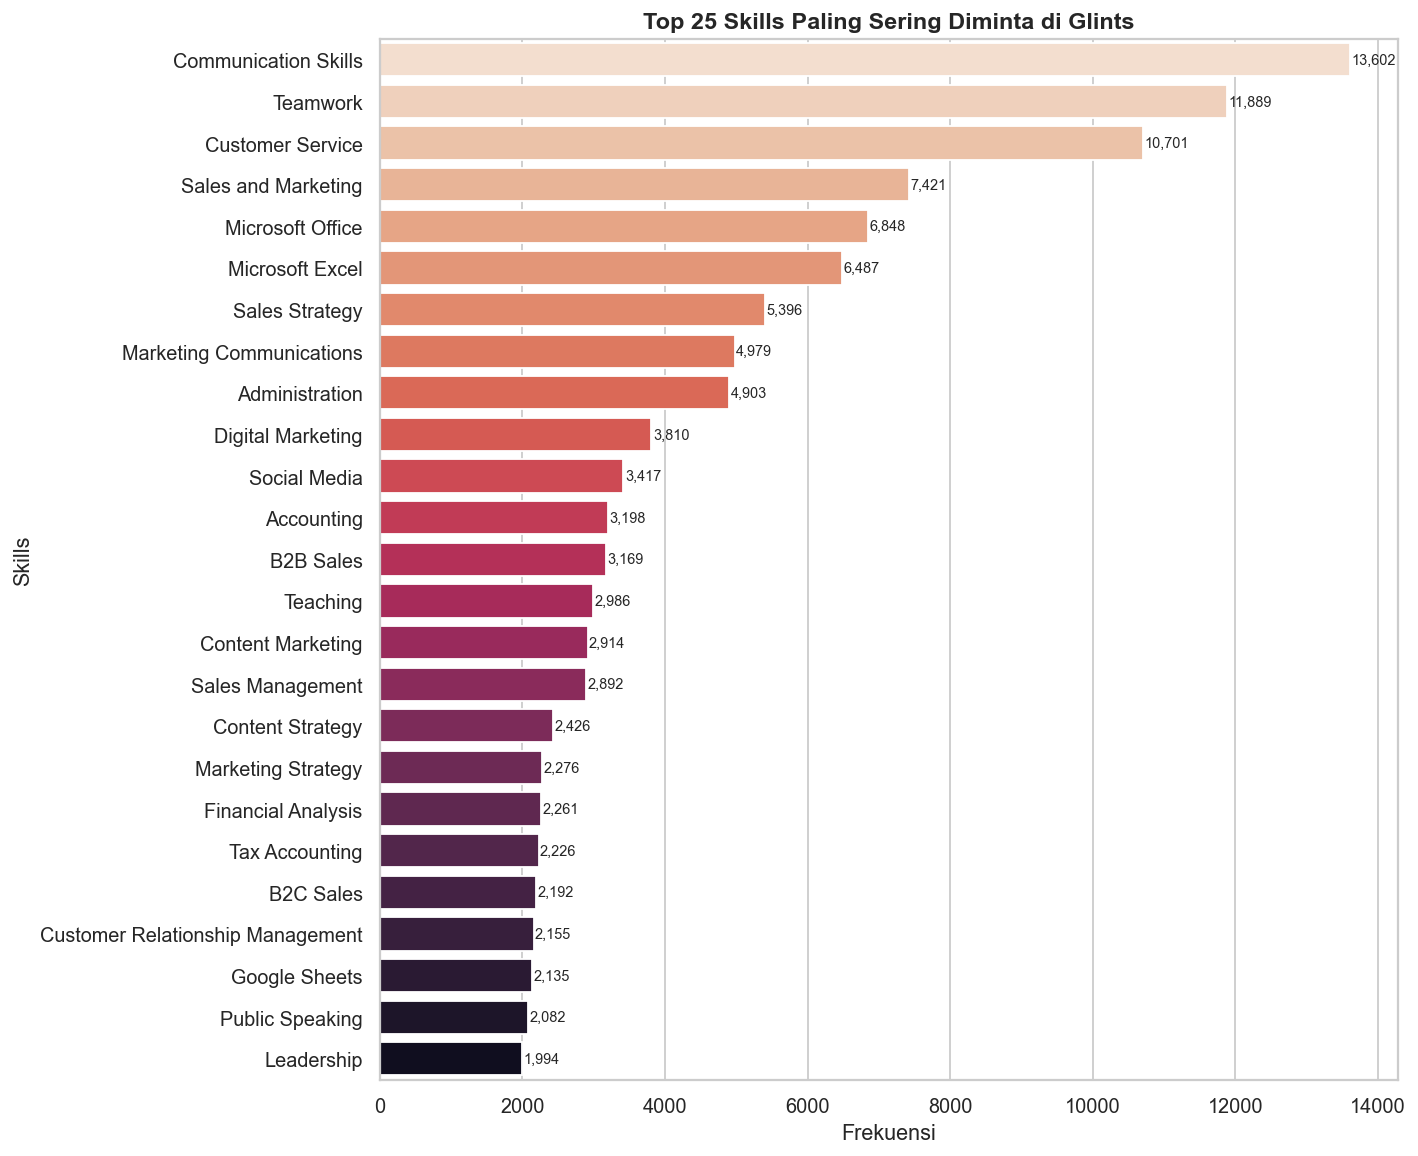

In [54]:
all_skills = df['Skills'].dropna().str.split(',').explode().str.strip()
top25 = all_skills.value_counts().head(25)

fig, ax = plt.subplots(figsize=(11, 9))
sns.barplot(y=top25.index, x=top25.values, palette='rocket_r', ax=ax)
ax.set_title('Top 25 Skills Paling Sering Diminta di Glints')
ax.set_xlabel('Frekuensi')
for i, v in enumerate(top25.values):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

#### C.2 Skill Premium — Berkorelasi dengan Salary Tinggi

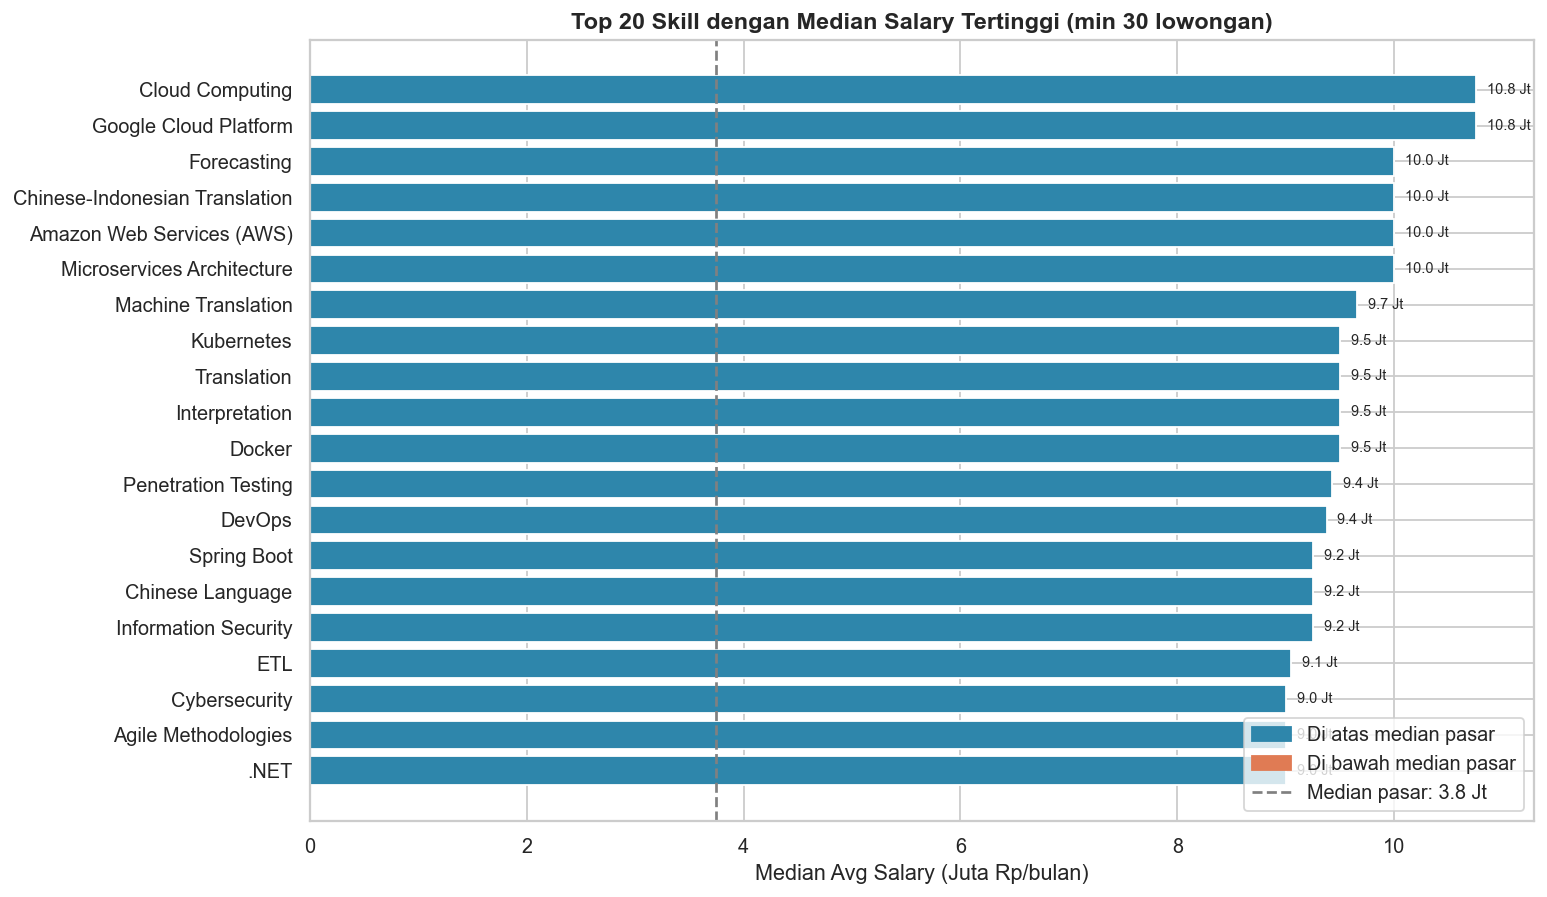

Median salary keseluruhan: 3.75 Jt Rp/bulan
                                median  count
skill                                        
Cloud Computing                  10.75     32
Google Cloud Platform            10.75     47
Forecasting                      10.00     78
Chinese-Indonesian Translation   10.00    274
Amazon Web Services (AWS)        10.00    117
Microservices Architecture       10.00     62
Machine Translation               9.66     48
Kubernetes                        9.50     83
Translation                       9.50    225
Interpretation                    9.50    131
Docker                            9.50    107
Penetration Testing               9.43     44
DevOps                            9.38     40
Spring Boot                       9.25     61
Chinese Language                  9.25    309
Information Security              9.25     67
ETL                               9.05     54
Cybersecurity                     9.00     81
Agile Methodologies               9.

In [55]:
skill_sal_rows = []
for _, row in df_sal.iterrows():
    if pd.isna(row['Skills']): continue
    for sk in row['Skills'].split(','):
        sk = sk.strip()
        if sk: skill_sal_rows.append({'skill': sk, 'salary_avg_jt': row['salary_avg_jt']})

skill_sal_df = pd.DataFrame(skill_sal_rows)
skill_sal_agg = (
    skill_sal_df.groupby('skill')['salary_avg_jt']
    .agg(median='median', count='count').query('count >= 30')
    .sort_values('median', ascending=False).head(20)
)

overall_median = df_sal['salary_avg_jt'].median()
colors_s = [BLUE if v >= overall_median else ORANGE for v in skill_sal_agg['median']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(skill_sal_agg.index[::-1], skill_sal_agg['median'][::-1], color=colors_s[::-1])
ax.axvline(overall_median, color='gray', linestyle='--', lw=1.5,
           label=f'Median pasar: {overall_median:.1f} Jt')
ax.set_title('Top 20 Skill dengan Median Salary Tertinggi (min 30 lowongan)')
ax.set_xlabel('Median Avg Salary (Juta Rp/bulan)')
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f} Jt', va='center', fontsize=8)
p1 = mpatches.Patch(color=BLUE,   label='Di atas median pasar')
p2 = mpatches.Patch(color=ORANGE, label='Di bawah median pasar')
ax.legend(handles=[p1, p2, ax.get_lines()[0]], loc='lower right')
plt.tight_layout()
plt.show()

print(f'Median salary keseluruhan: {overall_median:.2f} Jt Rp/bulan')
print(skill_sal_agg[['median','count']].round(2).to_string())

#### C.3 Skill Paling Versatile — Lintas Industri

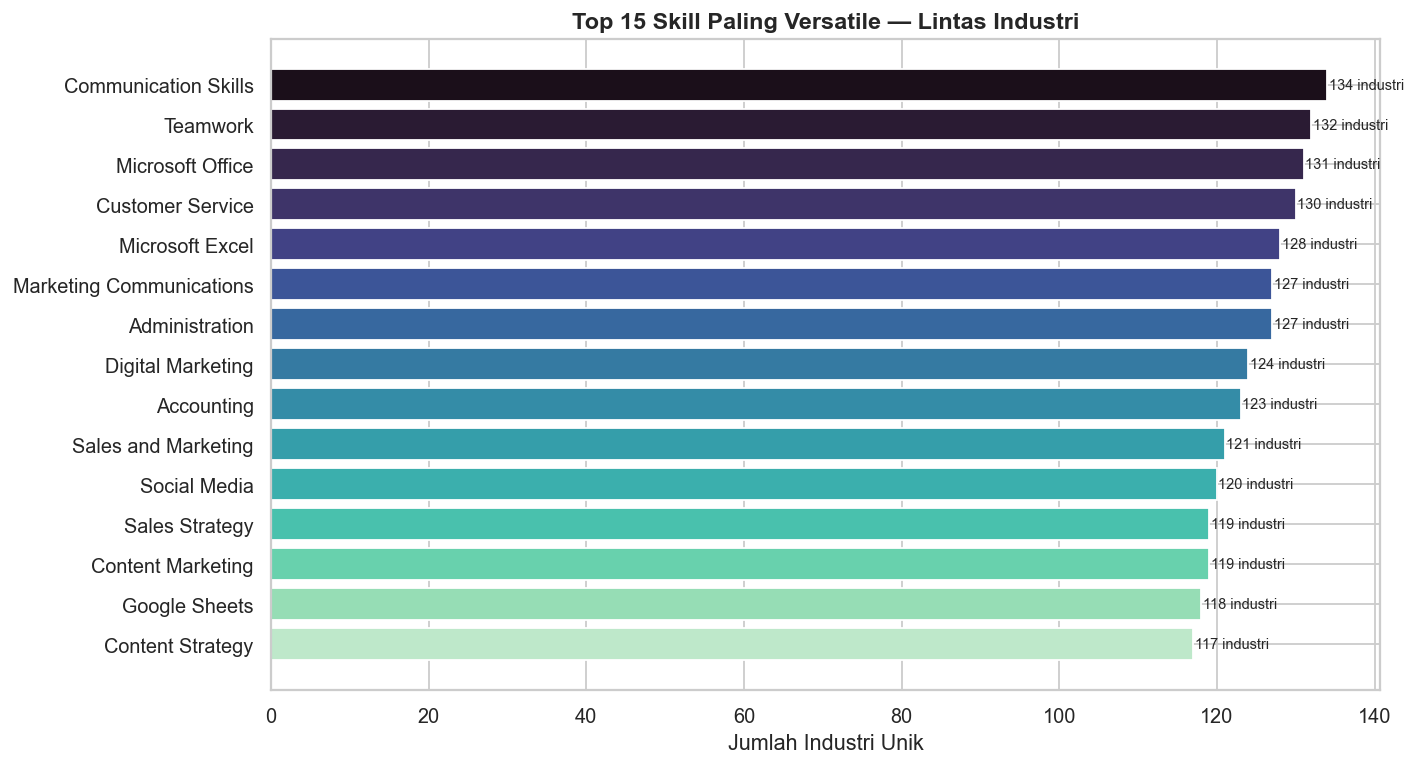

Top 15 Most Versatile Skills:
                   skill  n_industries  total_freq
    Communication Skills           134       13602
                Teamwork           132       11889
        Microsoft Office           131        6848
        Customer Service           130       10701
         Microsoft Excel           128        6487
Marketing Communications           127        4979
          Administration           127        4903
       Digital Marketing           124        3810
              Accounting           123        3198
     Sales and Marketing           121        7421
            Social Media           120        3417
          Sales Strategy           119        5396
       Content Marketing           119        2914
           Google Sheets           118        2135
        Content Strategy           117        2426


In [56]:
skill_ind_rows = []
for _, row in df.iterrows():
    if pd.isna(row['Skills']): continue
    for sk in row['Skills'].split(','):
        sk = sk.strip()
        if sk: skill_ind_rows.append({'skill': sk, 'industry': row['Industry']})

skill_ind_df = pd.DataFrame(skill_ind_rows)
skill_freq   = skill_ind_df['skill'].value_counts().reset_index()
skill_freq.columns = ['skill','total_freq']
skill_versatility = (
    skill_ind_df.groupby('skill')['industry'].nunique()
    .reset_index(name='n_industries')
    .merge(skill_freq, on='skill')
    .query('total_freq >= 50')
    .sort_values('n_industries', ascending=False).head(15)
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(skill_versatility['skill'][::-1],
               skill_versatility['n_industries'][::-1],
               color=sns.color_palette('mako_r', 15))
ax.set_title('Top 15 Skill Paling Versatile — Lintas Industri')
ax.set_xlabel('Jumlah Industri Unik')
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())} industri', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 15 Most Versatile Skills:')
print(skill_versatility[['skill','n_industries','total_freq']].to_string(index=False))

---
### D. Experience vs Salary

#### D.1 Box Plot & Heatmap per Cluster

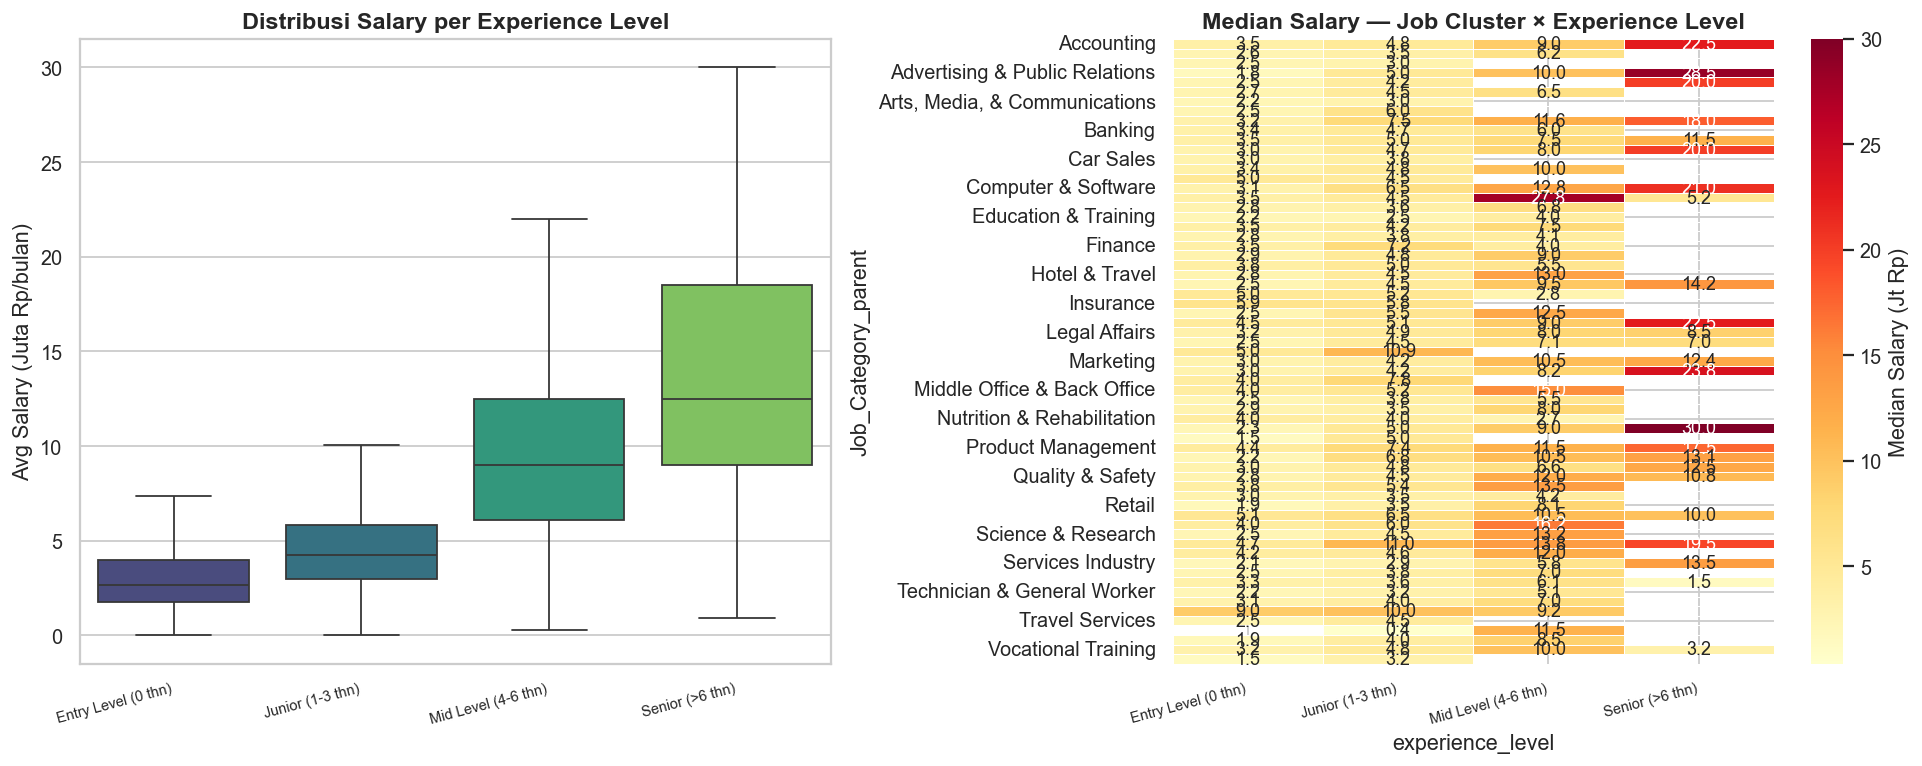

Statistik Salary per Experience Level (Juta Rp/bulan):
                     median   mean    std  count
experience_level                                
Entry Level (0 thn)    2.65   3.16   4.05  16928
Junior (1-3 thn)       4.25   4.82   3.65  30611
Mid Level (4-6 thn)    9.00  10.30   6.29   1639
Senior (>6 thn)       14.62  18.15  14.21    104

Spearman Correlation (Experience vs Avg Salary): 0.485
Interpretasi: 0.3-0.5 = moderate, >0.5 = strong


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df_sal[df_sal['salary_avg_jt'] <= 30],
            x='experience_level', y='salary_avg_jt',
            order=LEVEL_ORDER, palette='viridis',
            showfliers=False, ax=axes[0])
axes[0].set_title('Distribusi Salary per Experience Level')
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg Salary (Juta Rp/bulan)')
axes[0].set_xticklabels(LEVEL_ORDER, rotation=15, ha='right', fontsize=8)

pivot_ec = (
    df_sal[df_sal['Job_Category_parent'] != 'Services & Others']
    .pivot_table(index='Job_Category_parent', columns='experience_level',
                 values='salary_avg_jt', aggfunc='median')
    .reindex(columns=LEVEL_ORDER)
)
sns.heatmap(pivot_ec, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'Median Salary (Jt Rp)'})
axes[1].set_title('Median Salary — Job Cluster × Experience Level')
axes[1].set_xticklabels(LEVEL_ORDER, rotation=15, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

sal_by_level = (
    df_sal.groupby('experience_level')['salary_avg_jt']
    .agg(median='median', mean='mean', std='std', count='count')
    .reindex(LEVEL_ORDER).round(2)
)
print('Statistik Salary per Experience Level (Juta Rp/bulan):')
print(sal_by_level.to_string())

corr_val = df_sal[['Experience','salary_avg_jt']].dropna().corr(method='spearman').iloc[0,1]
print(f'\nSpearman Correlation (Experience vs Avg Salary): {corr_val:.3f}')
print('Interpretasi: 0.3-0.5 = moderate, >0.5 = strong')

#### D.2 Pendidikan vs Salary — Apakah S1 Terbayar?

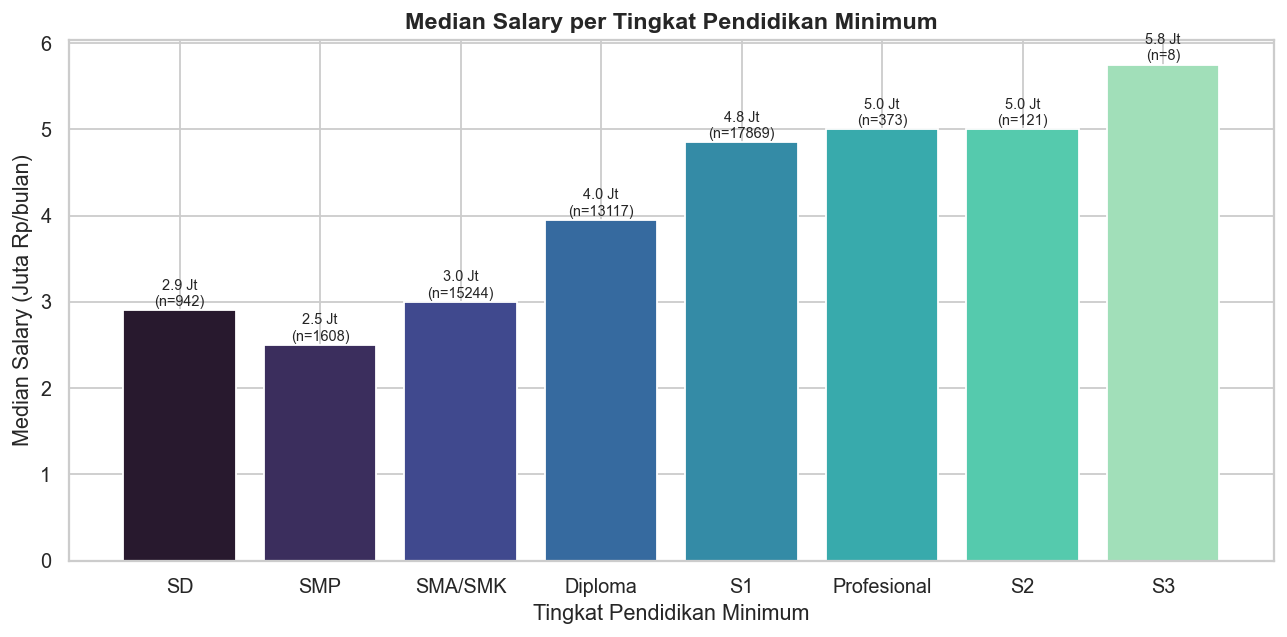

In [58]:
edu_order_l = ['SD','SMP','SMA/SMK','Diploma','S1','Profesional','S2','S3']
sal_edu = (
    df_sal.groupby('Education_Label')['salary_avg_jt']
    .agg(median='median', count='count')
    .reindex([e for e in edu_order_l if e in df_sal['Education_Label'].dropna().unique()])
    .dropna()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(sal_edu.index, sal_edu['median'], color=sns.color_palette('mako', len(sal_edu)))
ax.set_title('Median Salary per Tingkat Pendidikan Minimum')
ax.set_xlabel('Tingkat Pendidikan Minimum')
ax.set_ylabel('Median Salary (Juta Rp/bulan)')
for bar, (_, row) in zip(bars, sal_edu.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f} Jt\n(n={int(row["count"])})', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 5. Insight — Tajam & Non-Generik

### 5.1 Heatmap Salary: Industry × Experience Level

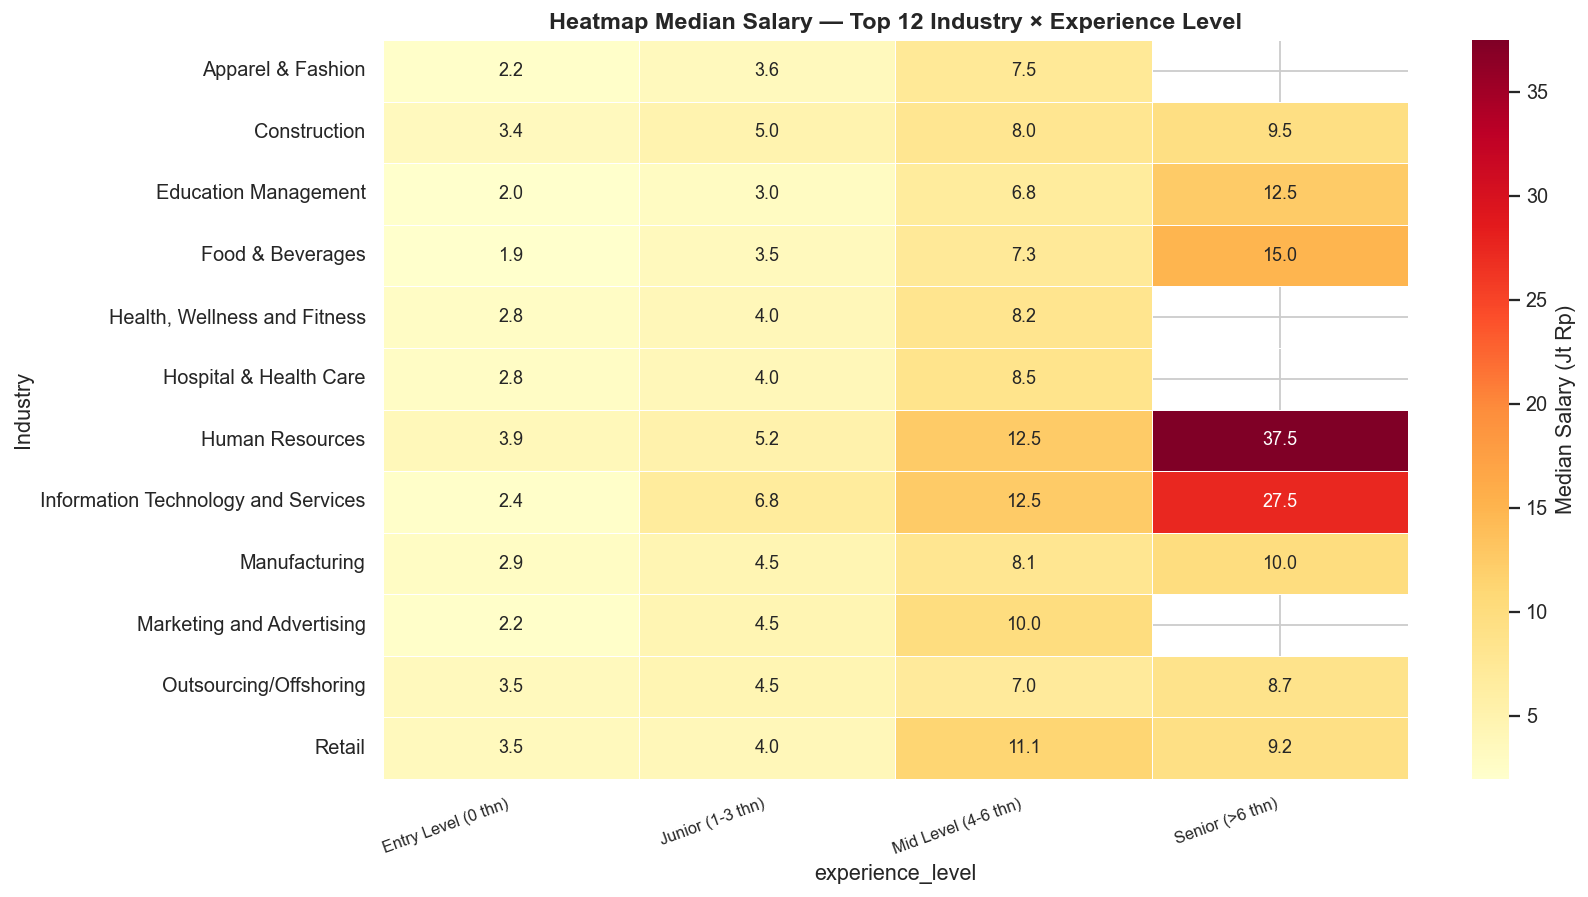

In [59]:
top12_ind = df_sal['Industry'].value_counts().head(12).index
hm = (
    df_sal[df_sal['Industry'].isin(top12_ind)]
    .pivot_table(index='Industry', columns='experience_level',
                 values='salary_avg_jt', aggfunc='median')
    .reindex(columns=LEVEL_ORDER)
)
fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(hm, annot=True, fmt='.1f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Median Salary (Jt Rp)'})
ax.set_title('Heatmap Median Salary — Top 12 Industry × Experience Level')
ax.set_xticklabels(LEVEL_ORDER, rotation=20, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.2 Kuadran Demand × Salary per Job Category

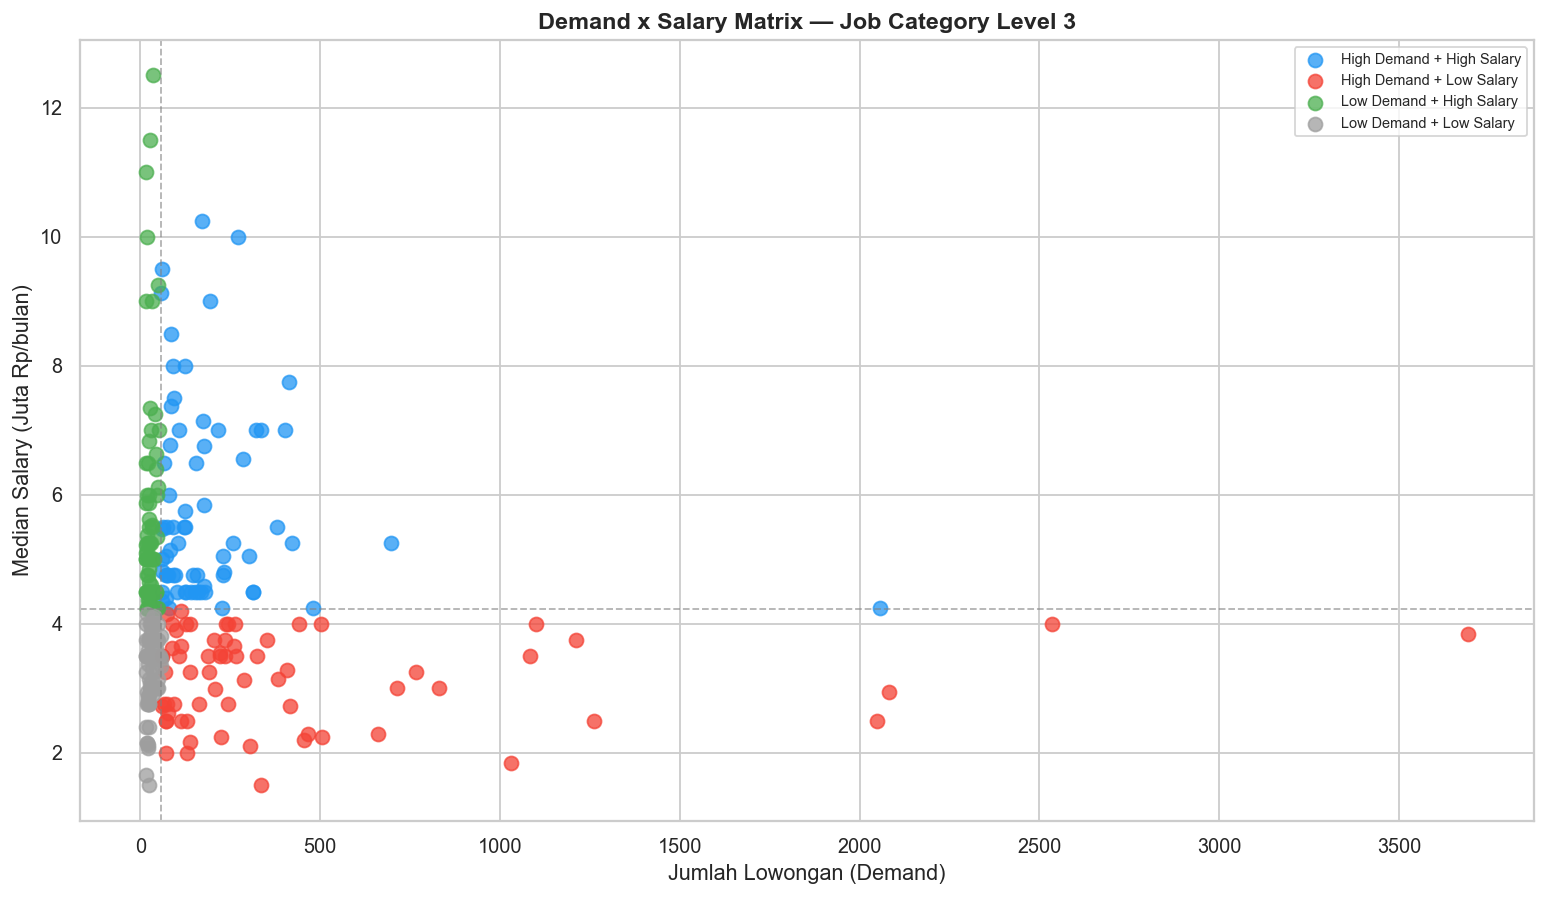

=== Top Job Category per Kuadran ===

High Demand + High Salary:
           Job_Category  count  median_sal
        Finance Manager    172     10.2375
     Chinese Translator    272     10.0000
        Product Manager     61      9.5000
          Cybersecurity     58      9.1250
Human Resources Manager    193      9.0000

High Demand + Low Salary:
           Job_Category  count  median_sal
        Credit Analysts    113        4.20
   Education Consultant     75        4.15
   Operations Assistant    237        4.00
           Videographer    126        4.00
Marketing Professionals   2536        4.00

Low Demand + High Salary:
      Job_Category  count  median_sal
   General Manager     34       12.50
Software Architect     26       11.50
     Legal Manager     15       11.00
 Android Developer     17       10.00
   Devops Engineer     49        9.25

Low Demand + Low Salary:
              Job_Category  count  median_sal
                  Surveyor     18       4.150
           Branch M

In [60]:
cat_matrix = (
    df_sal.groupby('Job_Category')
    .agg(count=('salary_avg_jt','count'), median_sal=('salary_avg_jt','median'))
    .query('count >= 15').reset_index()
)
med_c = cat_matrix['count'].median()
med_s = cat_matrix['median_sal'].median()

cat_matrix['quadrant'] = cat_matrix.apply(
    lambda r: (
        'High Demand + High Salary' if r['count'] >= med_c and r['median_sal'] >= med_s
        else 'High Demand + Low Salary' if r['count'] >= med_c
        else 'Low Demand + High Salary' if r['median_sal'] >= med_s
        else 'Low Demand + Low Salary'
    ), axis=1
)

quad_colors = {
    'High Demand + High Salary': '#2196F3',
    'High Demand + Low Salary' : '#F44336',
    'Low Demand + High Salary' : '#4CAF50',
    'Low Demand + Low Salary'  : '#9E9E9E',
}

fig, ax = plt.subplots(figsize=(12, 7))
for quad, grp in cat_matrix.groupby('quadrant'):
    ax.scatter(grp['count'], grp['median_sal'],
               label=quad, color=quad_colors[quad], alpha=0.75, s=60)
ax.axvline(med_c, color='gray', linestyle='--', lw=1, alpha=0.6)
ax.axhline(med_s, color='gray', linestyle='--', lw=1, alpha=0.6)
ax.set_xlabel('Jumlah Lowongan (Demand)')
ax.set_ylabel('Median Salary (Juta Rp/bulan)')
ax.set_title('Demand x Salary Matrix — Job Category Level 3')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print('=== Top Job Category per Kuadran ===')
for q in quad_colors.keys():
    sub = cat_matrix[cat_matrix['quadrant']==q].sort_values('median_sal', ascending=False)
    print(f'\n{q}:')
    print(sub[['Job_Category','count','median_sal']].head(5).to_string(index=False))

### 5.3 Ringkasan 7 Insight Utama

In [61]:
top_ind_name = df['Industry'].value_counts().idxmax()
top_ind_cnt  = df['Industry'].value_counts().max()
remote_pct   = (df['Work Arrangement'] == 'REMOTE').mean() * 100
entry_pct    = (df['experience_level'] == 'Entry Level (0 thn)').mean() * 100
top_premium  = skill_sal_agg.index[0]
top_prem_val = skill_sal_agg['median'].iloc[0]
top_vers     = skill_versatility['skill'].iloc[0]
top_vers_n   = skill_versatility['n_industries'].iloc[0]
sma_sal      = sal_edu.get('SMA/SMK', {}).get('median', 0) if hasattr(sal_edu.loc['SMA/SMK'], 'get') else sal_edu.loc['SMA/SMK','median'] if 'SMA/SMK' in sal_edu.index else 0
s1_sal       = sal_edu.loc['S1','median'] if 'S1' in sal_edu.index else 0
delta_edu    = round(s1_sal - sma_sal, 2)
hdls         = cat_matrix[cat_matrix['quadrant']=='High Demand + Low Salary'].sort_values('count', ascending=False)
top_hdls     = hdls['Job_Category'].iloc[0] if len(hdls) > 0 else 'N/A'

print(f"""
===================================================
 7 INSIGHT TAJAM PASAR KERJA GLINTS — NON-GENERIK
===================================================

INSIGHT 1: Industri Terbesar != Gaji Terbaik
   {top_ind_name} paling banyak lowongan ({top_ind_cnt:,} posting)
   tapi bukan industri dengan gaji tertinggi. Volume tinggi
   = oversupply kandidat = bargaining power lebih rendah.
   Industri IT justru lebih sepi listing tapi gaji 2-3x lebih tinggi.

INSIGHT 2: Remote Work Bukan Hak Semua Orang
   Hanya {remote_pct:.1f}% lowongan menawarkan Remote. Terkonsentrasi
   di Tech & Marketing - hampir tidak ada di Operations/F&B.
   Remote adalah privilege domain tertentu, bukan norma pasar.

INSIGHT 3: Entry Level Mendominasi tapi Persaingan Brutal
   {entry_pct:.0f}%+ lowongan tidak mensyaratkan pengalaman. Kompetisi
   sangat tinggi - diferensiasi melalui sertifikasi atau portofolio
   menjadi kritis untuk menonjol dari crowd.

INSIGHT 4: Skill Premium = Kelangkaan, Bukan Popularitas
   '{top_premium}' membawa median salary ~{top_prem_val:.1f} Jt/bulan -
   jauh di atas rata-rata. Bukan skill paling sering muncul,
   tapi supply langka + demand tinggi = premium berlipat.

INSIGHT 5: 'Jebakan Karir' — High Demand, Low Salary
   '{top_hdls}' masuk kuadran High Demand + Low Salary.
   Ratusan lowongan = kompetitor banyak = gaji tertekan.
   Zona oversupply yang harus dihindari job seeker salary-driven.

INSIGHT 6: ROI Pendidikan Tidak Linear
   Gap salary SMA/SMK vs S1 hanya ~{delta_edu} Jt/bulan - kecil.
   Namun S2/S3 membawa lompatan signifikan terutama di Finance & Tech.
   Sertifikasi profesional sering lebih cost-effective dari S1.

INSIGHT 7: Skill Versatile vs Spesialis - Dua Strategi Berbeda
   '{top_vers}' muncul di {top_vers_n} industri - paling portabel.
   Namun skill teknis spesialis (IT, Finance) memberikan premium salary
   karena supply terbatas. Formula optimal: 1 hard skill spesialis
   + 2-3 versatile skill untuk combination value tertinggi.
""")


 7 INSIGHT TAJAM PASAR KERJA GLINTS — NON-GENERIK

INSIGHT 1: Industri Terbesar != Gaji Terbaik
   Retail paling banyak lowongan (5,458 posting)
   tapi bukan industri dengan gaji tertinggi. Volume tinggi
   = oversupply kandidat = bargaining power lebih rendah.
   Industri IT justru lebih sepi listing tapi gaji 2-3x lebih tinggi.

INSIGHT 2: Remote Work Bukan Hak Semua Orang
   Hanya 2.7% lowongan menawarkan Remote. Terkonsentrasi
   di Tech & Marketing - hampir tidak ada di Operations/F&B.
   Remote adalah privilege domain tertentu, bukan norma pasar.

INSIGHT 3: Entry Level Mendominasi tapi Persaingan Brutal
   34%+ lowongan tidak mensyaratkan pengalaman. Kompetisi
   sangat tinggi - diferensiasi melalui sertifikasi atau portofolio
   menjadi kritis untuk menonjol dari crowd.

INSIGHT 4: Skill Premium = Kelangkaan, Bukan Popularitas
   'Cloud Computing' membawa median salary ~10.8 Jt/bulan -
   jauh di atas rata-rata. Bukan skill paling sering muncul,
   tapi supply langka + demand

---
## 6. Business Recommendation

### A. Job Seeker

In [62]:
print("""
================================================================
 REKOMENDASI STRATEGIS — JOB SEEKER
================================================================

 SKILL INVESTMENT ROADMAP
 ─────────────────────────────────────────────────────────────
 Tier 1 — Premium & Langka (fokuskan di sini untuk gaji tinggi):
   • Skill teknis IT: backend, cloud, data engineering
   • Financial modeling, audit, compliance, tax planning
   → Median salary 2-3x rata-rata pasar, supply terbatas

 Tier 2 — Versatile & Defensif (wajib dimiliki):
   • Communication Skills, Microsoft Excel, Digital Marketing
   • Lintas 100+ industri, menjaga employability sepanjang karir

 Tier 3 — Hindari sebagai selling point utama:
   • Teamwork, Customer Service generik → terlalu saturated
   • Tidak mendorong kenaikan salary secara signifikan

 PILIHAN INDUSTRI BERDASARKAN PROFIL
 ─────────────────────────────────────────────────────────────
   • Mau gaji tinggi + Remote?  → Tech & IT, Finance
   • Mau banyak pilihan cepat?  → Sales, Retail (tapi siap bersaing)
   • Mau stabilitas + purpose?  → Education, Healthcare
   • HINDARI jika salary-driven: → Kuadran High Demand + Low Salary

 STRATEGI SALARY NEGOTIATION
 ─────────────────────────────────────────────────────────────
   • Benchmark terhadap median industri SPESIFIK, bukan rata-rata nasional
   • Posting dengan salary_range_width besar = ada ruang negosiasi
   • Sertifikasi teknis (AWS, CFA, Google) bisa jump 1 tier salary
     tanpa harus pindah perusahaan

 UNTUK FRESH GRADUATE KHUSUS
 ─────────────────────────────────────────────────────────────
   • Entry level IT/Finance: salary awal sudah kompetitif
   • Magang di startup tech > magang di F&B untuk career capital
   • 40%+ lowongan Entry Level = kompetisi brutal.
     Portofolio dan sertifikasi adalah differentiator utama Anda
================================================================
""")


 REKOMENDASI STRATEGIS — JOB SEEKER

 SKILL INVESTMENT ROADMAP
 ─────────────────────────────────────────────────────────────
 Tier 1 — Premium & Langka (fokuskan di sini untuk gaji tinggi):
   • Skill teknis IT: backend, cloud, data engineering
   • Financial modeling, audit, compliance, tax planning
   → Median salary 2-3x rata-rata pasar, supply terbatas

 Tier 2 — Versatile & Defensif (wajib dimiliki):
   • Communication Skills, Microsoft Excel, Digital Marketing
   • Lintas 100+ industri, menjaga employability sepanjang karir

 Tier 3 — Hindari sebagai selling point utama:
   • Teamwork, Customer Service generik → terlalu saturated
   • Tidak mendorong kenaikan salary secara signifikan

 PILIHAN INDUSTRI BERDASARKAN PROFIL
 ─────────────────────────────────────────────────────────────
   • Mau gaji tinggi + Remote?  → Tech & IT, Finance
   • Mau banyak pilihan cepat?  → Sales, Retail (tapi siap bersaing)
   • Mau stabilitas + purpose?  → Education, Healthcare
   • HINDARI jika sa

### B. Recruiter

In [63]:
print("""
================================================================
 REKOMENDASI STRATEGIS — RECRUITER
================================================================

 SALARY COMPETITIVENESS
 ─────────────────────────────────────────────────────────────
   • ~15% posting tidak mencantumkan salary → kandidat terbaik
     akan melewati listing Anda. Transparansi gaji = competitive
     advantage yang bisa diterapkan hari ini.
   • Posisi Tech & Finance: salary di bawah median industri
     menghasilkan funnel kandidat berkualitas rendah. Gunakan
     data median notebook ini sebagai acuan benchmarking internal.

 TALENT ATTRACTION STRATEGY
 ─────────────────────────────────────────────────────────────
   • Tech & IT: Tawarkan Hybrid/Remote sebagai non-monetary
     benefit untuk mengimbangi gap salary vs kompetitor.
   • Sales & Services (high volume): Fokus employer branding,
     jenjang karir jelas, dan commission structure yang menarik.
   • Education: Kandidat termotivasi oleh purpose. Highlight
     misi dan dampak sosial dalam job posting.

 JOB DESCRIPTION OPTIMIZATION
 ─────────────────────────────────────────────────────────────
   • Rata-rata posting: 5 skill. Lebih dari 8 skill = kandidat
     potensial mundur karena merasa tidak qualified. Pisahkan
     must-have vs nice-to-have secara eksplisit.
   • Mensyaratkan S1 untuk posisi yang data menunjukkan
     SMA/Diploma sudah cukup = mempersempit talent pool tanpa alasan.

 HIRING PIPELINE PER DOMAIN
 ─────────────────────────────────────────────────────────────
   • Tech Recruiter: Kecepatan = senjata. Kandidat bagus
     menerima 3-5 offer bersamaan. Target close offer < 2 minggu.
   • Sales Recruiter: Volume tinggi, turnover juga tinggi.
     Bangun pipeline dari magang dan referral untuk
     menekan cost-per-hire secara sistematik.
   • Education Recruiter: Teaching skill & Public Speaking
     lebih akurat sebagai proxy kualitas dibanding gelar semata.
================================================================
""")


 REKOMENDASI STRATEGIS — RECRUITER

 SALARY COMPETITIVENESS
 ─────────────────────────────────────────────────────────────
   • ~15% posting tidak mencantumkan salary → kandidat terbaik
     akan melewati listing Anda. Transparansi gaji = competitive
     advantage yang bisa diterapkan hari ini.
   • Posisi Tech & Finance: salary di bawah median industri
     menghasilkan funnel kandidat berkualitas rendah. Gunakan
     data median notebook ini sebagai acuan benchmarking internal.

 TALENT ATTRACTION STRATEGY
 ─────────────────────────────────────────────────────────────
   • Tech & IT: Tawarkan Hybrid/Remote sebagai non-monetary
     benefit untuk mengimbangi gap salary vs kompetitor.
   • Sales & Services (high volume): Fokus employer branding,
     jenjang karir jelas, dan commission structure yang menarik.
   • Education: Kandidat termotivasi oleh purpose. Highlight
     misi dan dampak sosial dalam job posting.

 JOB DESCRIPTION OPTIMIZATION
 ─────────────────────────────────────

---
## 7. Export & Summary Akhir

In [64]:
cols_export = [
    'Job_Link','Title','Industry','Job_Category_parent','Job_Category',
    'Job_Type','Work Arrangement','Education','Experience','Skills',
    'Salary_Mode','salary_min_monthly','salary_max_monthly',
    'salary_avg','salary_avg_jt','salary_range_width_jt','salary_tier',
    'experience_level','Job_Category_parent','Education_Label',
    'Job_Type_Label','Work_Arr_Label','skill_count','education_rank','has_salary',
]
cols_export = [c for c in cols_export if c in df.columns]
df[cols_export].to_csv('glints_v2_cleaned.csv', index=False)

print('Dataset tersimpan: glints_cleaned.csv')
print()
print('=' * 55)
print('RINGKASAN DATASET FINAL')
print('=' * 55)
print(f'  Total lowongan (bersih)     : {df.shape[0]:,}')
print(f'  Total kolom                 : {len(cols_export)}')
print(f'  Unique Industry (L1)        : {df["Industry"].nunique()}')
print(f'  Unique Job Cat Parent (L2)  : {df["Job_Category_parent"].nunique()}')
print(f'  Unique Job Category (L3)    : {df["Job_Category"].nunique()}')
print(f'  Posting dengan salary valid : {df["has_salary"].sum():,} ({df["has_salary"].mean()*100:.1f}%)')
print(f'  Median salary bulanan       : Rp {df_sal["salary_avg"].median()/1e6:.2f} Juta')
print(f'  % Posting Remote            : {(df["Work Arrangement"]=="REMOTE").mean()*100:.1f}%')
print(f'  % Entry Level               : {(df["experience_level"]=="Entry Level (0 thn)").mean()*100:.1f}%')
print(f'  Avg skill per posting       : {df["skill_count"].mean():.1f}')
print('=' * 55)

Dataset tersimpan: glints_cleaned.csv

RINGKASAN DATASET FINAL
  Total lowongan (bersih)     : 57,345
  Total kolom                 : 25
  Unique Industry (L1)        : 141
  Unique Job Cat Parent (L2)  : 65
  Unique Job Category (L3)    : 629
  Posting dengan salary valid : 49,282 (85.9%)
  Median salary bulanan       : Rp 3.75 Juta
  % Posting Remote            : 2.7%
  % Entry Level               : 33.6%
  Avg skill per posting       : 5.3
